**Unsupervised learning** is a type of machine learning that discovers hidden patterns and structures in **unlabeled data**. A primary example of this is **clustering**, where algorithms like **k-means** automatically group similar data points together without any pre-existing labels to guide them.

## Supervised vs. Unsupervised Learning

The fundamental difference between the two machine learning paradigms lies in the data they use and the goals they aim to achieve.

  * **Supervised Learning**: This is "learning with an answer key." The algorithm is trained on a labeled dataset, meaning it has access to both the input **features** and the correct output **target**. Its goal is to learn a mapping function to make accurate **predictions** on new data.

  * **Unsupervised Learning**: This is "learning without an answer key." The algorithm is given only the input **features** and must discover inherent patterns, structures, or relationships within the data on its own. Its goal is **pattern discovery** and data representation. The two main tasks in unsupervised learning are:

      * **Clustering**: Grouping similar data points together.
      * **Dimensionality Reduction**: Compressing the data by finding a more efficient representation of its features.

### k-Means Clustering

**k-Means clustering** is one of the most popular and intuitive clustering algorithms. Its objective is to partition a dataset into `k` distinct, non-overlapping clusters.

  * **The Goal**: To group the data points such that the total variance within each cluster is minimized. Each data point is assigned to the cluster whose mean (or **centroid**) is closest.
  * **The "k" Hyperparameter**: A key aspect of k-means is that `k`, the number of clusters, is a **hyperparameter** that you must specify *before* the algorithm runs.

The algorithm works by iteratively assigning data points to the nearest centroid and then updating the centroid's position to be the mean of the points assigned to it, repeating this process until the cluster assignments stabilize.

### Clustering with `scikit-learn`

Let's walk through a complete example of performing k-means clustering on the well-known Iris dataset. Although this dataset has true labels (the species), we will ignore them and see if the unsupervised algorithm can rediscover these natural groupings on its own.

```python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# 1. Load and Prepare the Data
# The Iris dataset contains measurements for 3 species of iris flowers.
iris = load_iris()
# We use only the features for our unsupervised task.
samples = iris.data

# 2. Instantiate and Fit the k-Means Model
# We specify k=3 because we have a prior belief that there are three groups (species).
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(samples)

# 3. Get the Cluster Labels for the Training Data
# The .labels_ attribute contains the cluster assignment for each sample.
predicted_labels = kmeans.labels_

# 4. Predict on New, Unseen Data
# The trained model can now assign new samples to the learned clusters.
new_samples = np.array([
    [5.7, 4.4, 1.5, 0.4], # Likely a Setosa
    [6.5, 3.0, 5.5, 1.8], # Likely a Virginica
    [5.8, 2.7, 4.1, 1.0]  # Likely a Versicolor
])
new_labels = kmeans.predict(new_samples)
print(new_labels)

# 5. Visualize the Clustering Results
# We create a DataFrame for easier plotting with seaborn.
df = pd.DataFrame(samples, columns=iris.feature_names)
df['predicted_cluster'] = predicted_labels
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('k-Means Clustering vs. True Species Labels', fontsize=16)

# Plot 1: Points colored by the k-means predicted cluster
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='predicted_cluster',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Clusters Found by k-Means')

# Plot 2: Points colored by the actual species
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Actual Species Labels')

plt.show()
```

**Interpretation**:
The side-by-side comparison is striking. The plot on the left shows the three distinct clusters that the k-means algorithm discovered purely from the geometric arrangement of the data points. The plot on the right shows the true species labels. We can see that the unsupervised algorithm did an excellent job of rediscovering the underlying species structure in the data without ever being told what a "Setosa" or "Versicolor" was. This demonstrates the power of unsupervised learning to find meaningful patterns in data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from data.points import points

xs = points[:, 0]
ys = points[:, 1]

display(points)

array([[ 0.06544649, -0.76866376],
       [-1.52901547, -0.42953079],
       [ 1.70993371,  0.69885253],
       [ 1.16779145,  1.01262638],
       [-1.80110088, -0.31861296],
       [-1.63567888, -0.02859535],
       [ 1.21990375,  0.74643463],
       [-0.26175155, -0.62492939],
       [-1.61925804, -0.47983949],
       [-1.84329582, -0.16694431],
       [ 1.35999602,  0.94995827],
       [ 0.42291856, -0.7349534 ],
       [-1.68576139,  0.10686728],
       [ 0.90629995,  1.09105162],
       [-1.56478322, -0.84675394],
       [-0.0257849 , -1.18672539],
       [ 0.83027324,  1.14504612],
       [ 1.22450432,  1.35066759],
       [-0.15394596, -0.71704301],
       [ 0.86358809,  1.06824613],
       [-1.43386366, -0.2381297 ],
       [ 0.03844769, -0.74635022],
       [-1.58567922,  0.08499354],
       [ 0.6359888 , -0.58477698],
       [ 0.24417242, -0.53172465],
       [-2.19680359,  0.49473677],
       [ 1.0323503 , -0.55688   ],
       [-0.28858067, -0.39972528],
       [ 0.20597008,

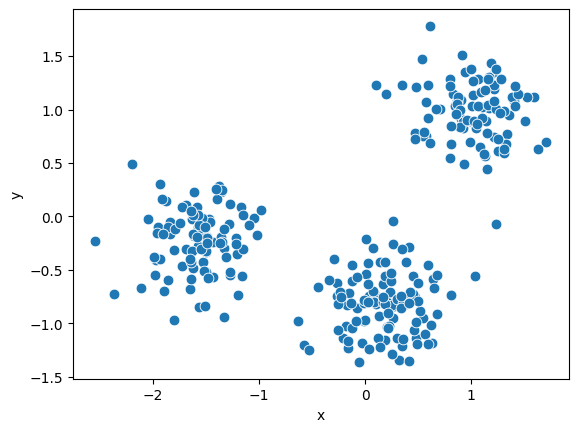

In [3]:
points_df = pd.DataFrame(points, columns=["x", "y"])


sns.scatterplot(data=points_df, x="x", y="y", s=60)
plt.show()

In [4]:
from sklearn.cluster import KMeans
from data.new_points import new_points

# Create a KMeans instance with 3 clusters: model
kmeans = KMeans(n_clusters=3)

# Fit model to points

kmeans.fit(points)

labels_points = kmeans.predict(points)

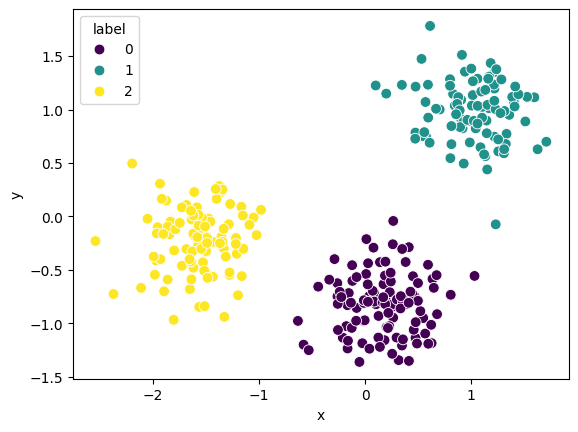

In [5]:
points_df = pd.DataFrame(points, columns=["x", "y"])
points_df["label"] = labels_points

sns.scatterplot(data=points_df, x="x", y="y", hue="label", palette="viridis", s=60)
plt.show()

In [6]:
# Determine the cluster labels of new_points: labels
labels_new_points = kmeans.predict(new_points)

# make a DataFrame tying new_points to their predicted labels, then plot
new_points_df = pd.DataFrame(new_points, columns=["x", "y"])
new_points_df["label"] = labels_new_points

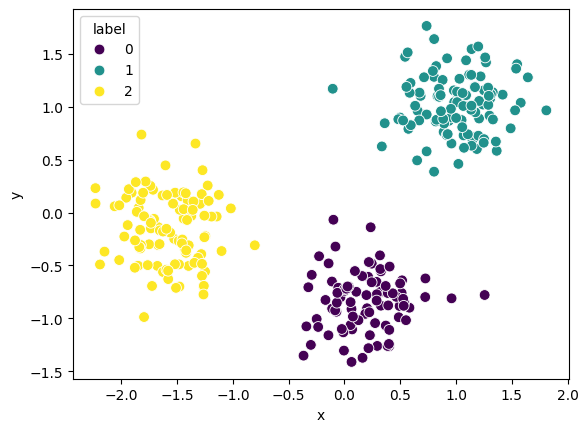

In [7]:
sns.scatterplot(data=new_points_df, x="x", y="y", hue="label", palette="viridis", s=60)
# optionally overlay kmeans centroids from the trained model

plt.show()

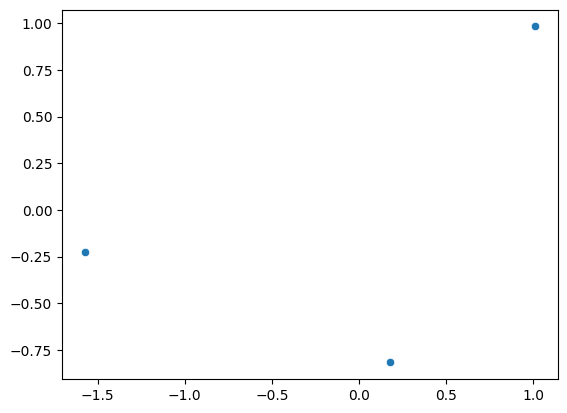

In [8]:
# Assign the cluster centers: centroids
centroids = kmeans.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y
centroids_x = centroids[:, 0]
centroids_y = centroids[:, 1]

# Make a scatter plot of centroids_x and centroids_y
sns.scatterplot(x=centroids_x, y=centroids_y)
plt.show()

In [9]:
bank_full_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/machine_learning/unsupervised_learning_with_scikit-learn/data/bank-full.csv"
bank = pd.read_csv(bank_full_url, usecols=lambda col: not col.startswith("Unnamed"))

In [10]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [11]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [12]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


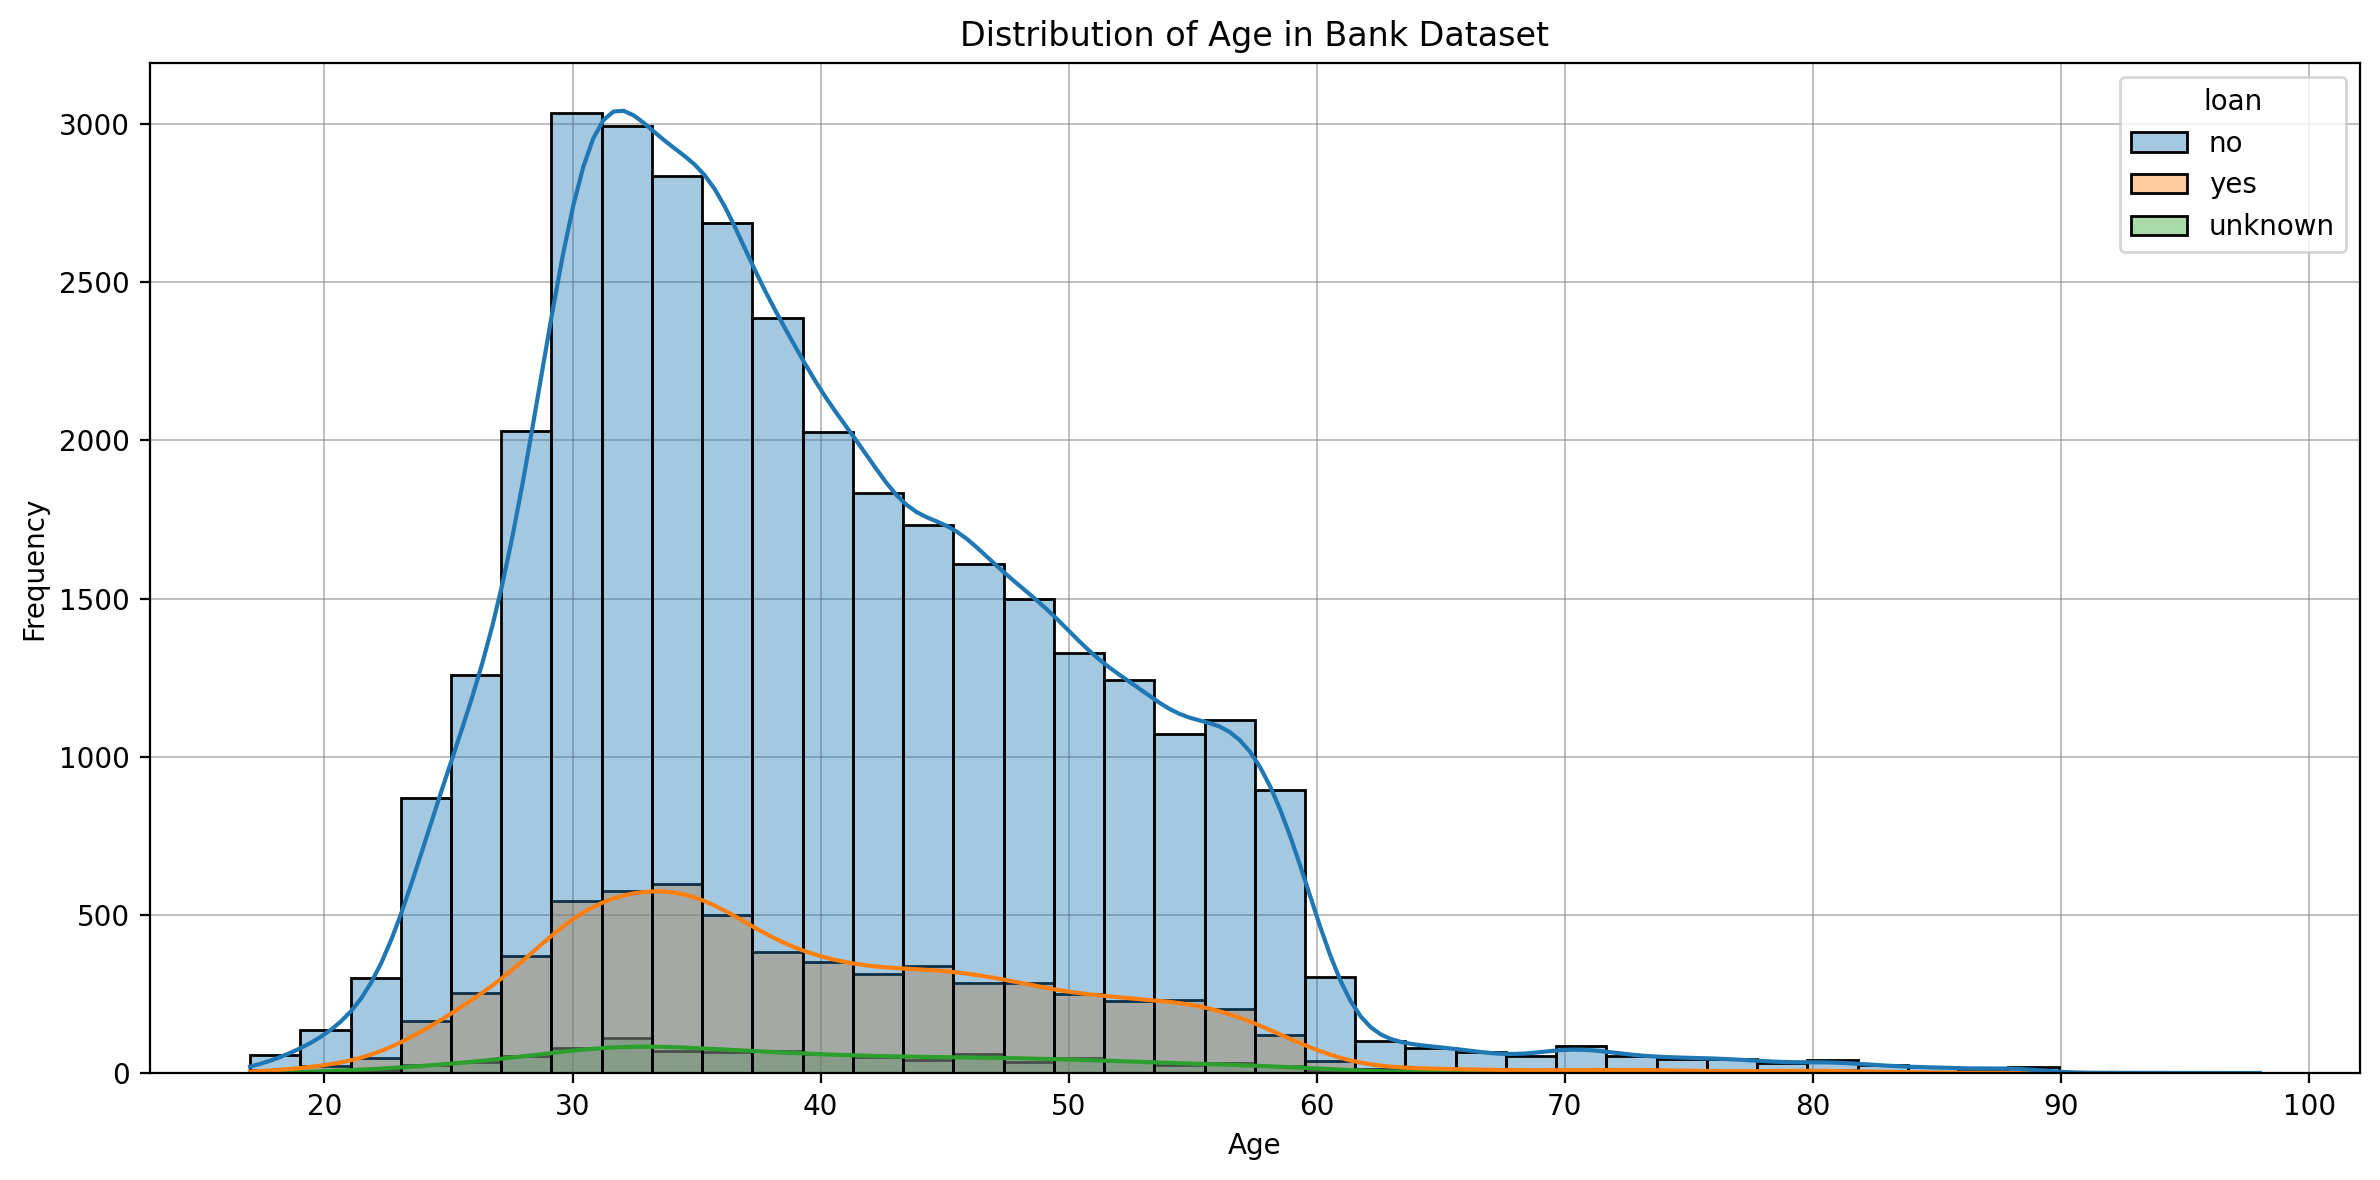

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
sns.histplot(data=bank, x="age", ax=ax, bins=40, kde=True, hue="loan", alpha=0.4)
ax.set(xlabel="Age", ylabel="Frequency", title="Distribution of Age in Bank Dataset")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

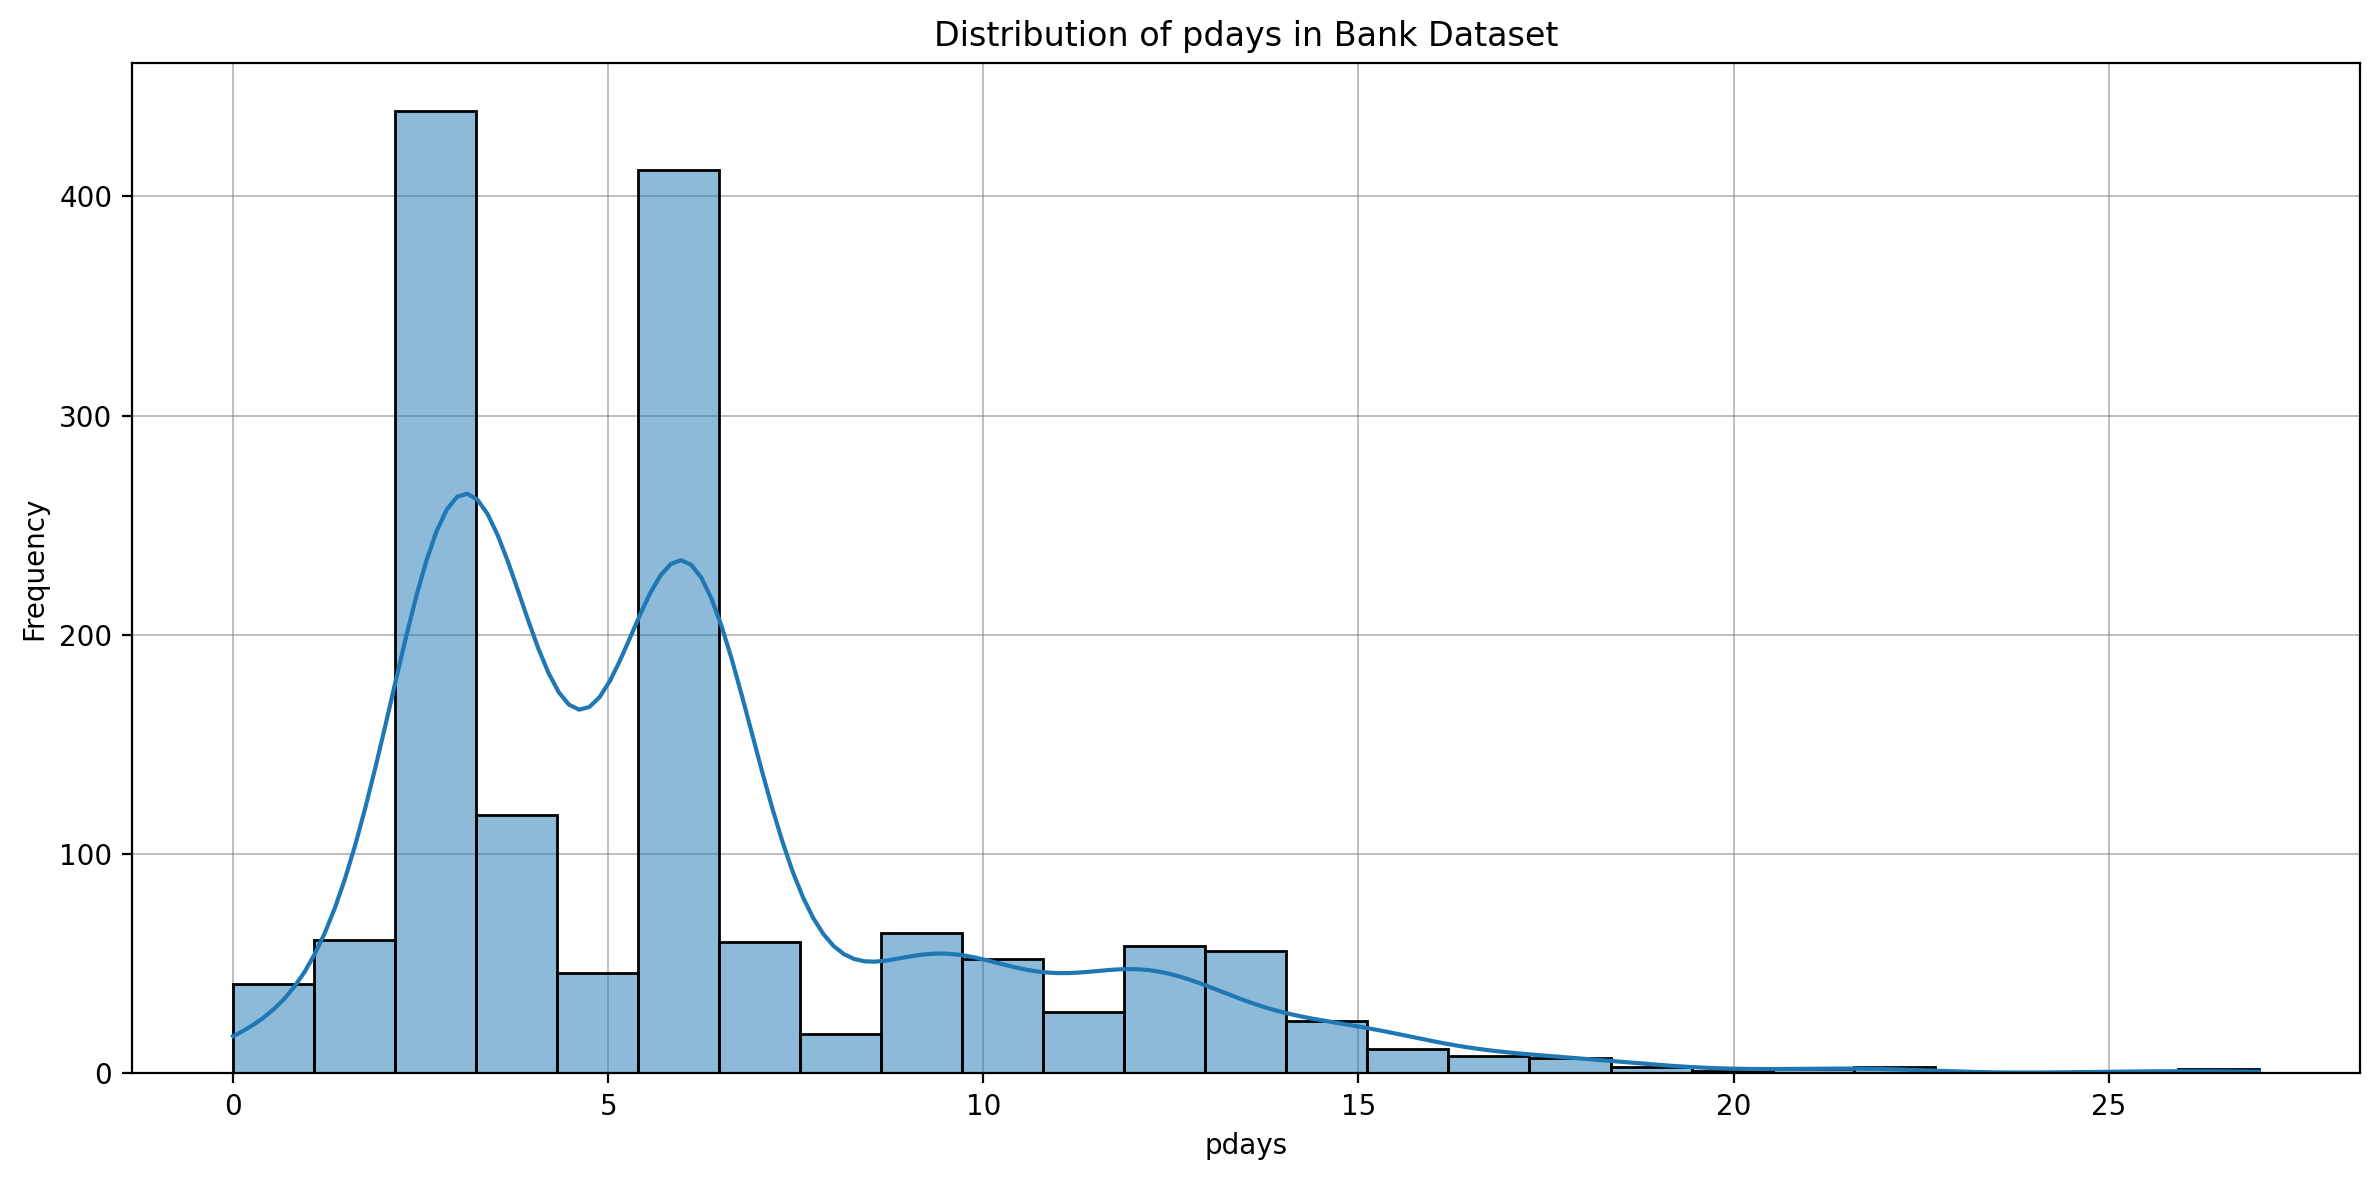

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
sns.histplot(
    data=bank[bank["pdays"] != 999],
    x="pdays",
    ax=ax,
    bins=25,
    kde=True,
)
ax.set(
    xlabel="pdays", ylabel="Frequency", title="Distribution of pdays in Bank Dataset"
)
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

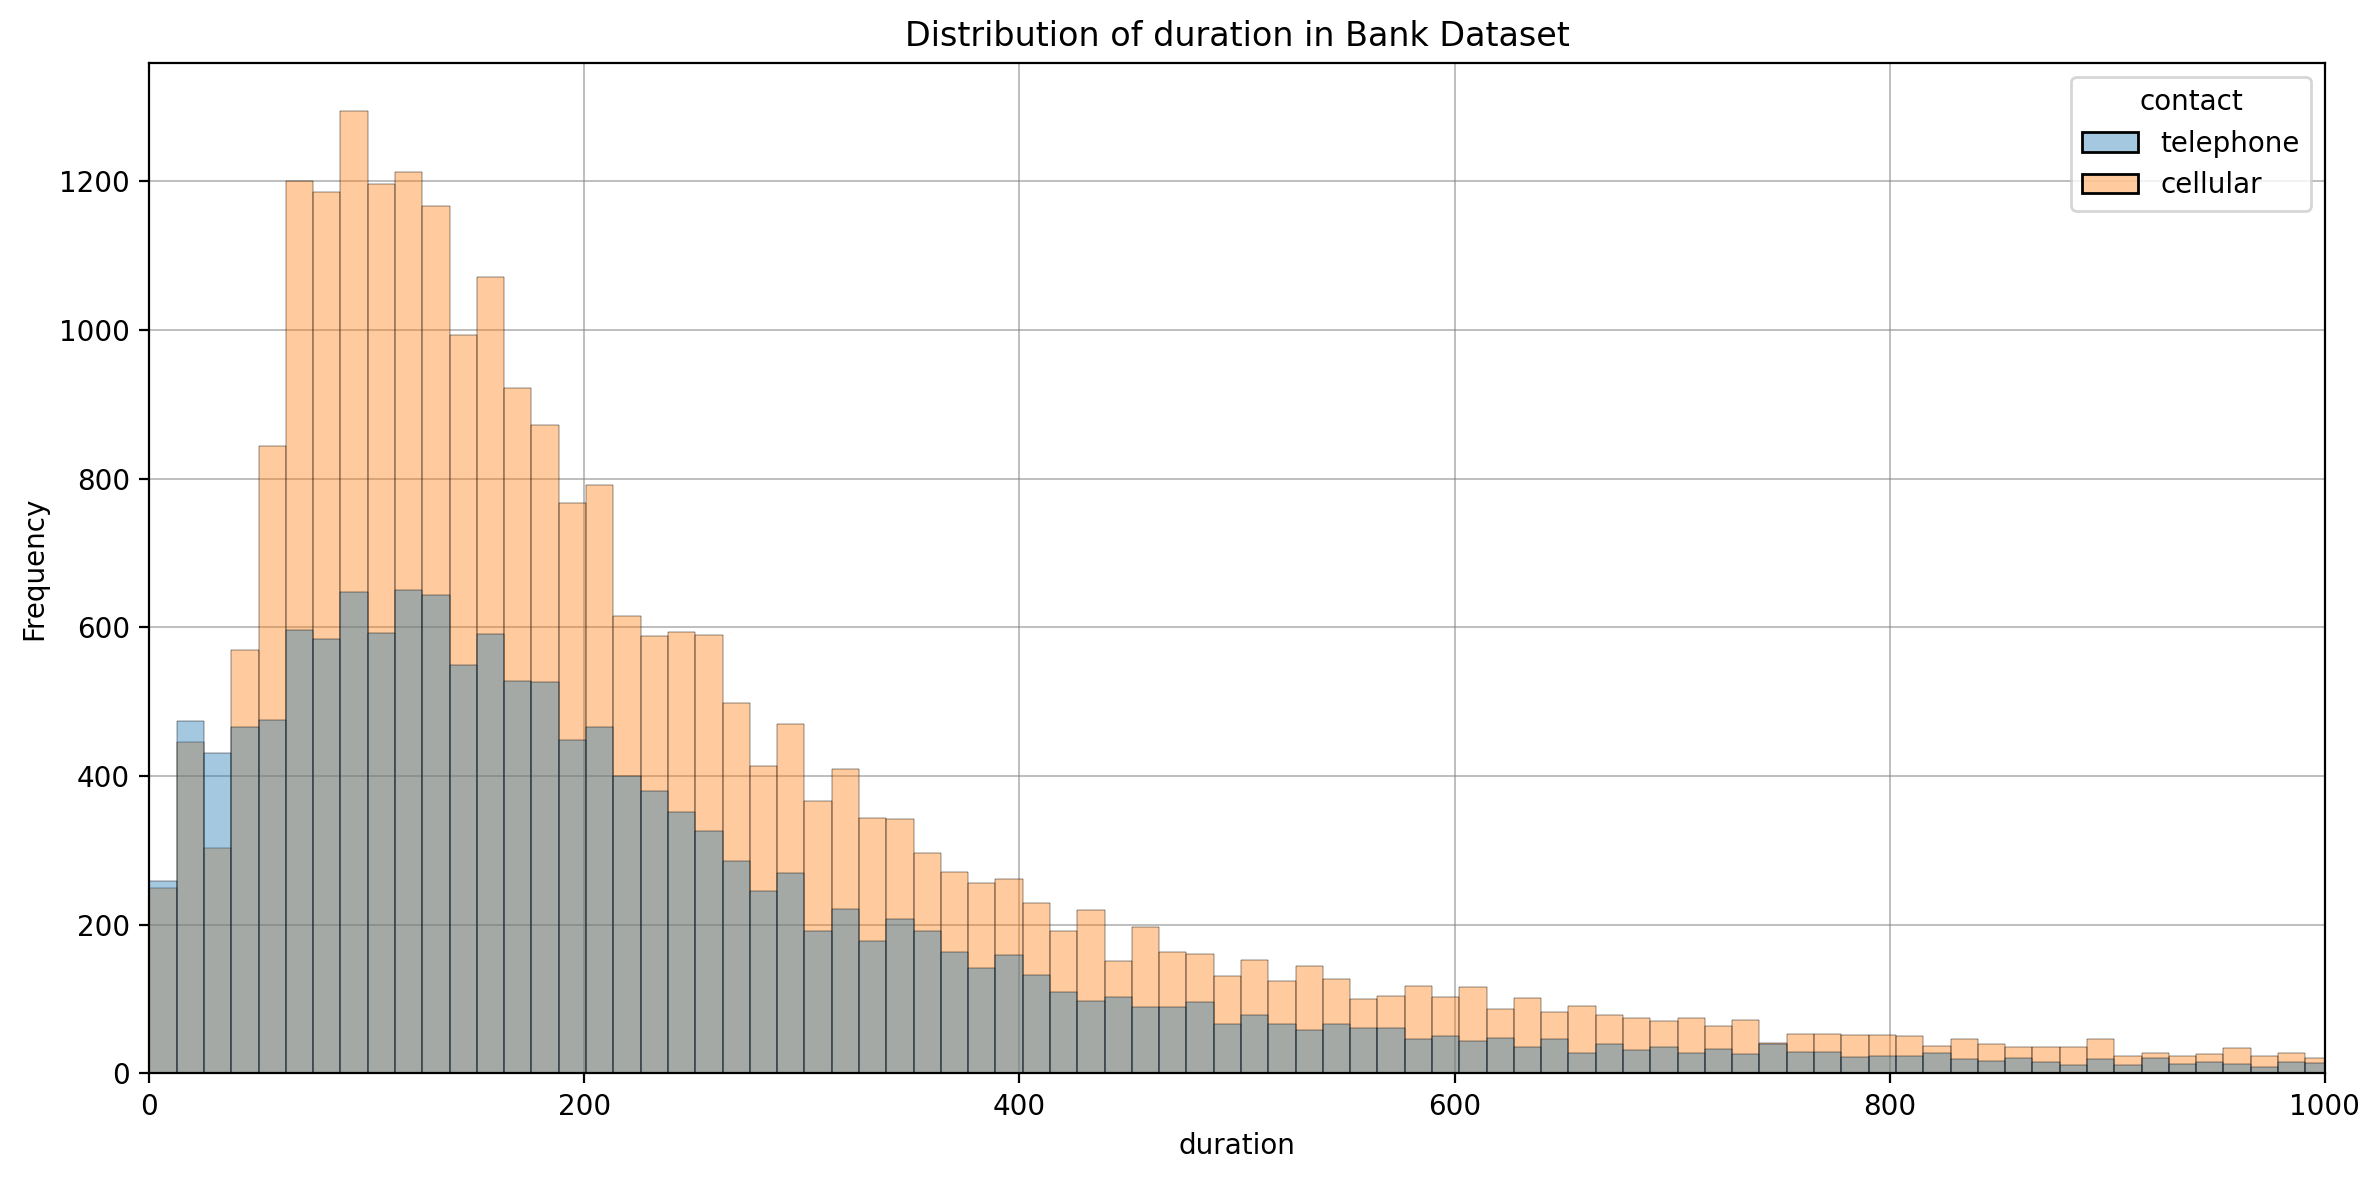

In [15]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
sns.histplot(data=bank, x="duration", ax=ax, hue="contact", alpha=0.4)
ax.set(
    xlabel="duration",
    ylabel="Frequency",
    title="Distribution of duration in Bank Dataset",
)
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)
ax.set_xlim(0, 1000)
plt.tight_layout()
plt.show()

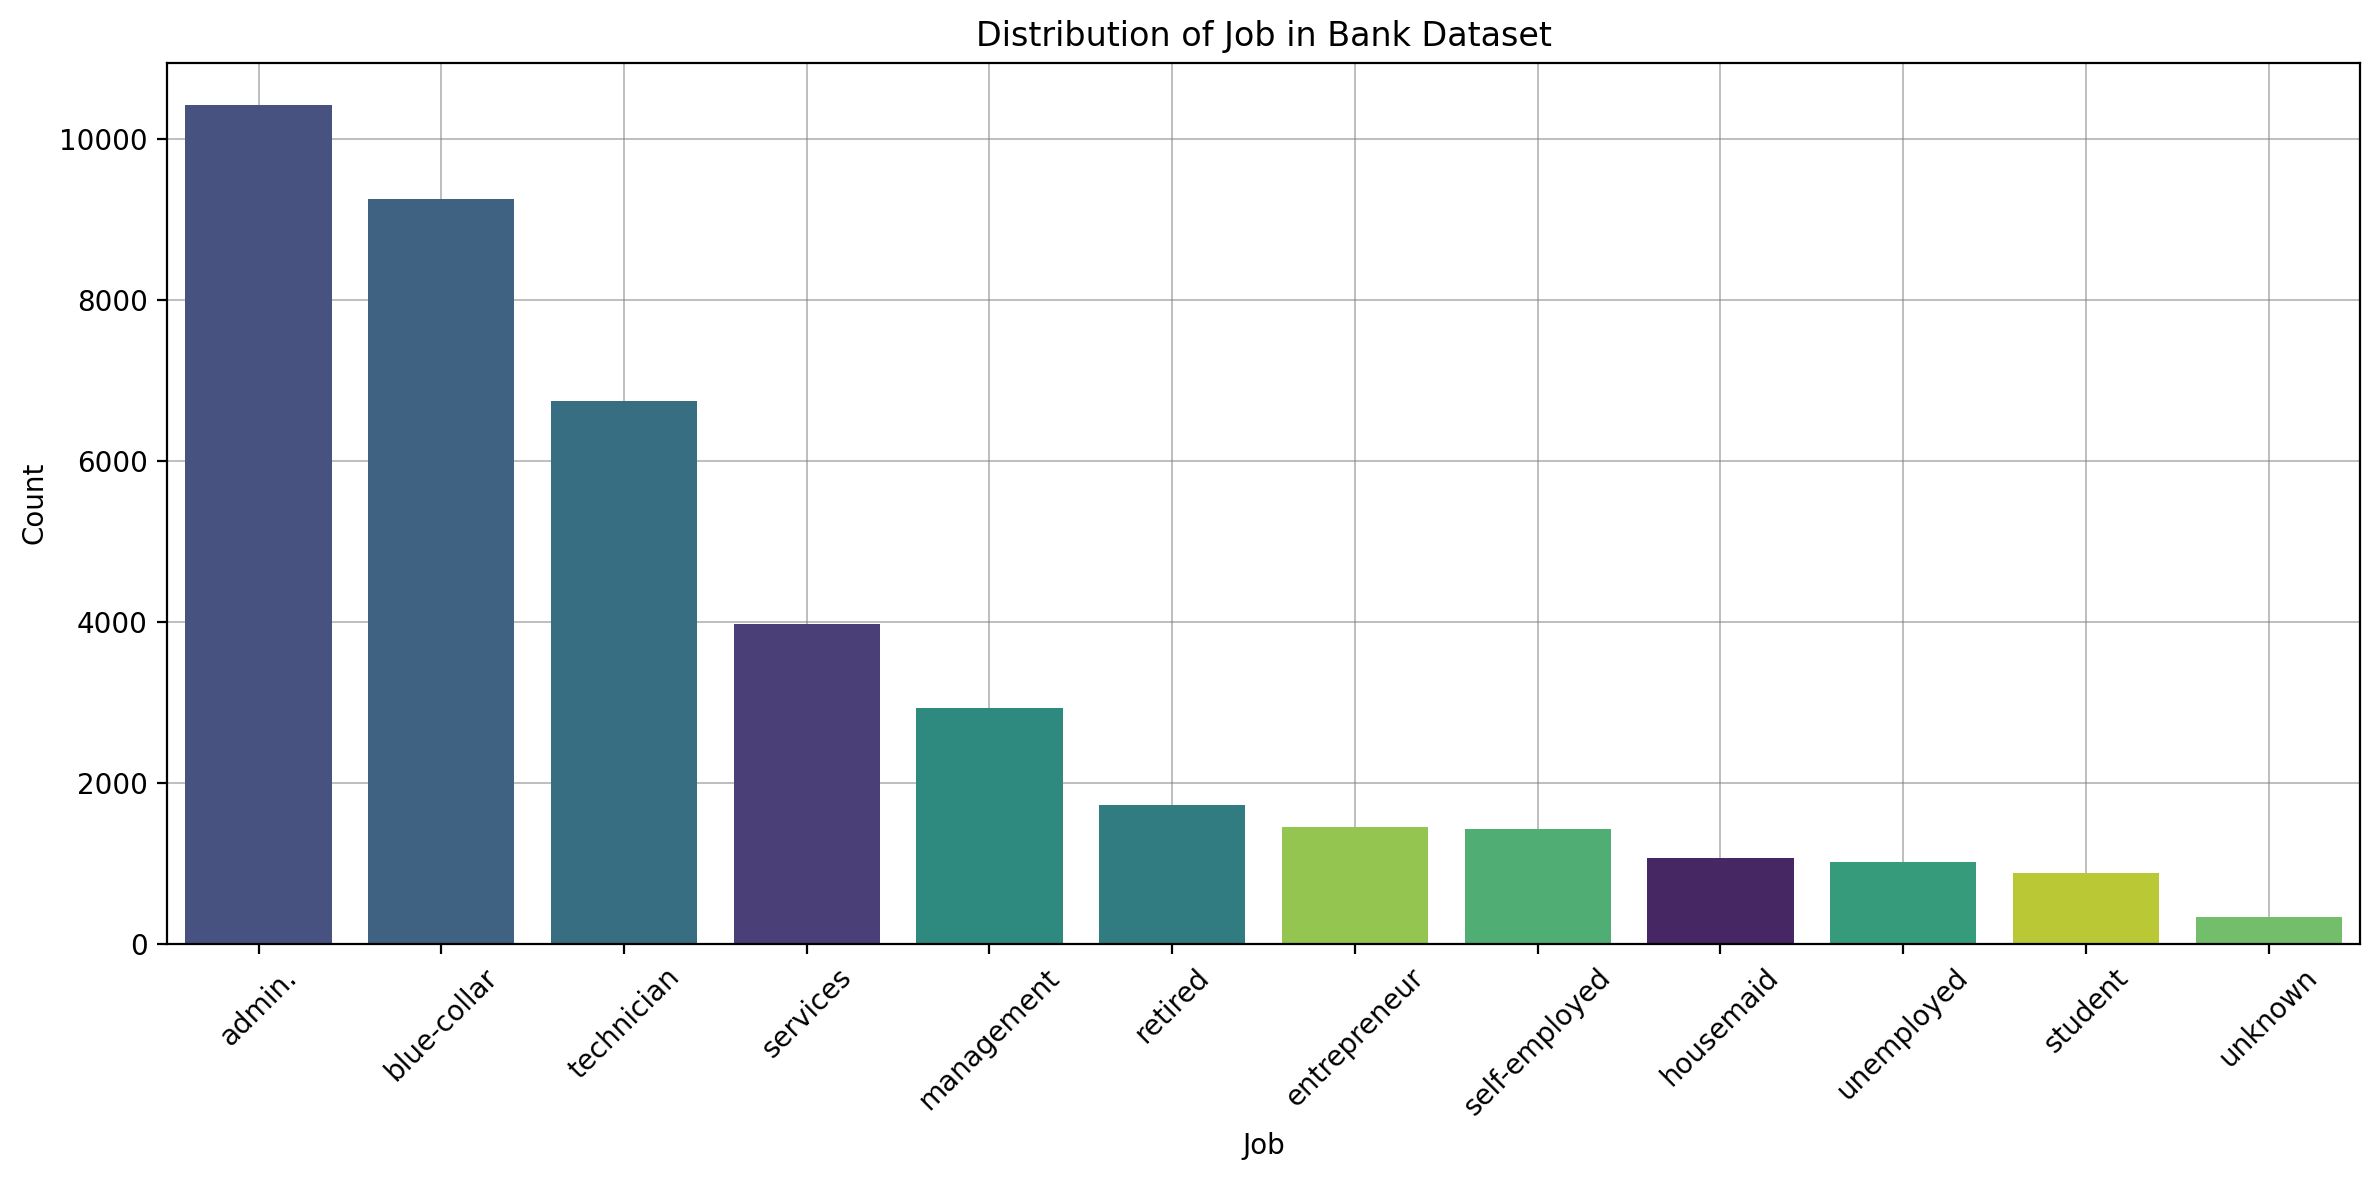

In [16]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
order = bank["job"].value_counts().index
sns.countplot(data=bank, x="job", order=order, ax=ax, hue="job", palette="viridis")
ax.set(xlabel="Job", ylabel="Count", title="Distribution of Job in Bank Dataset")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

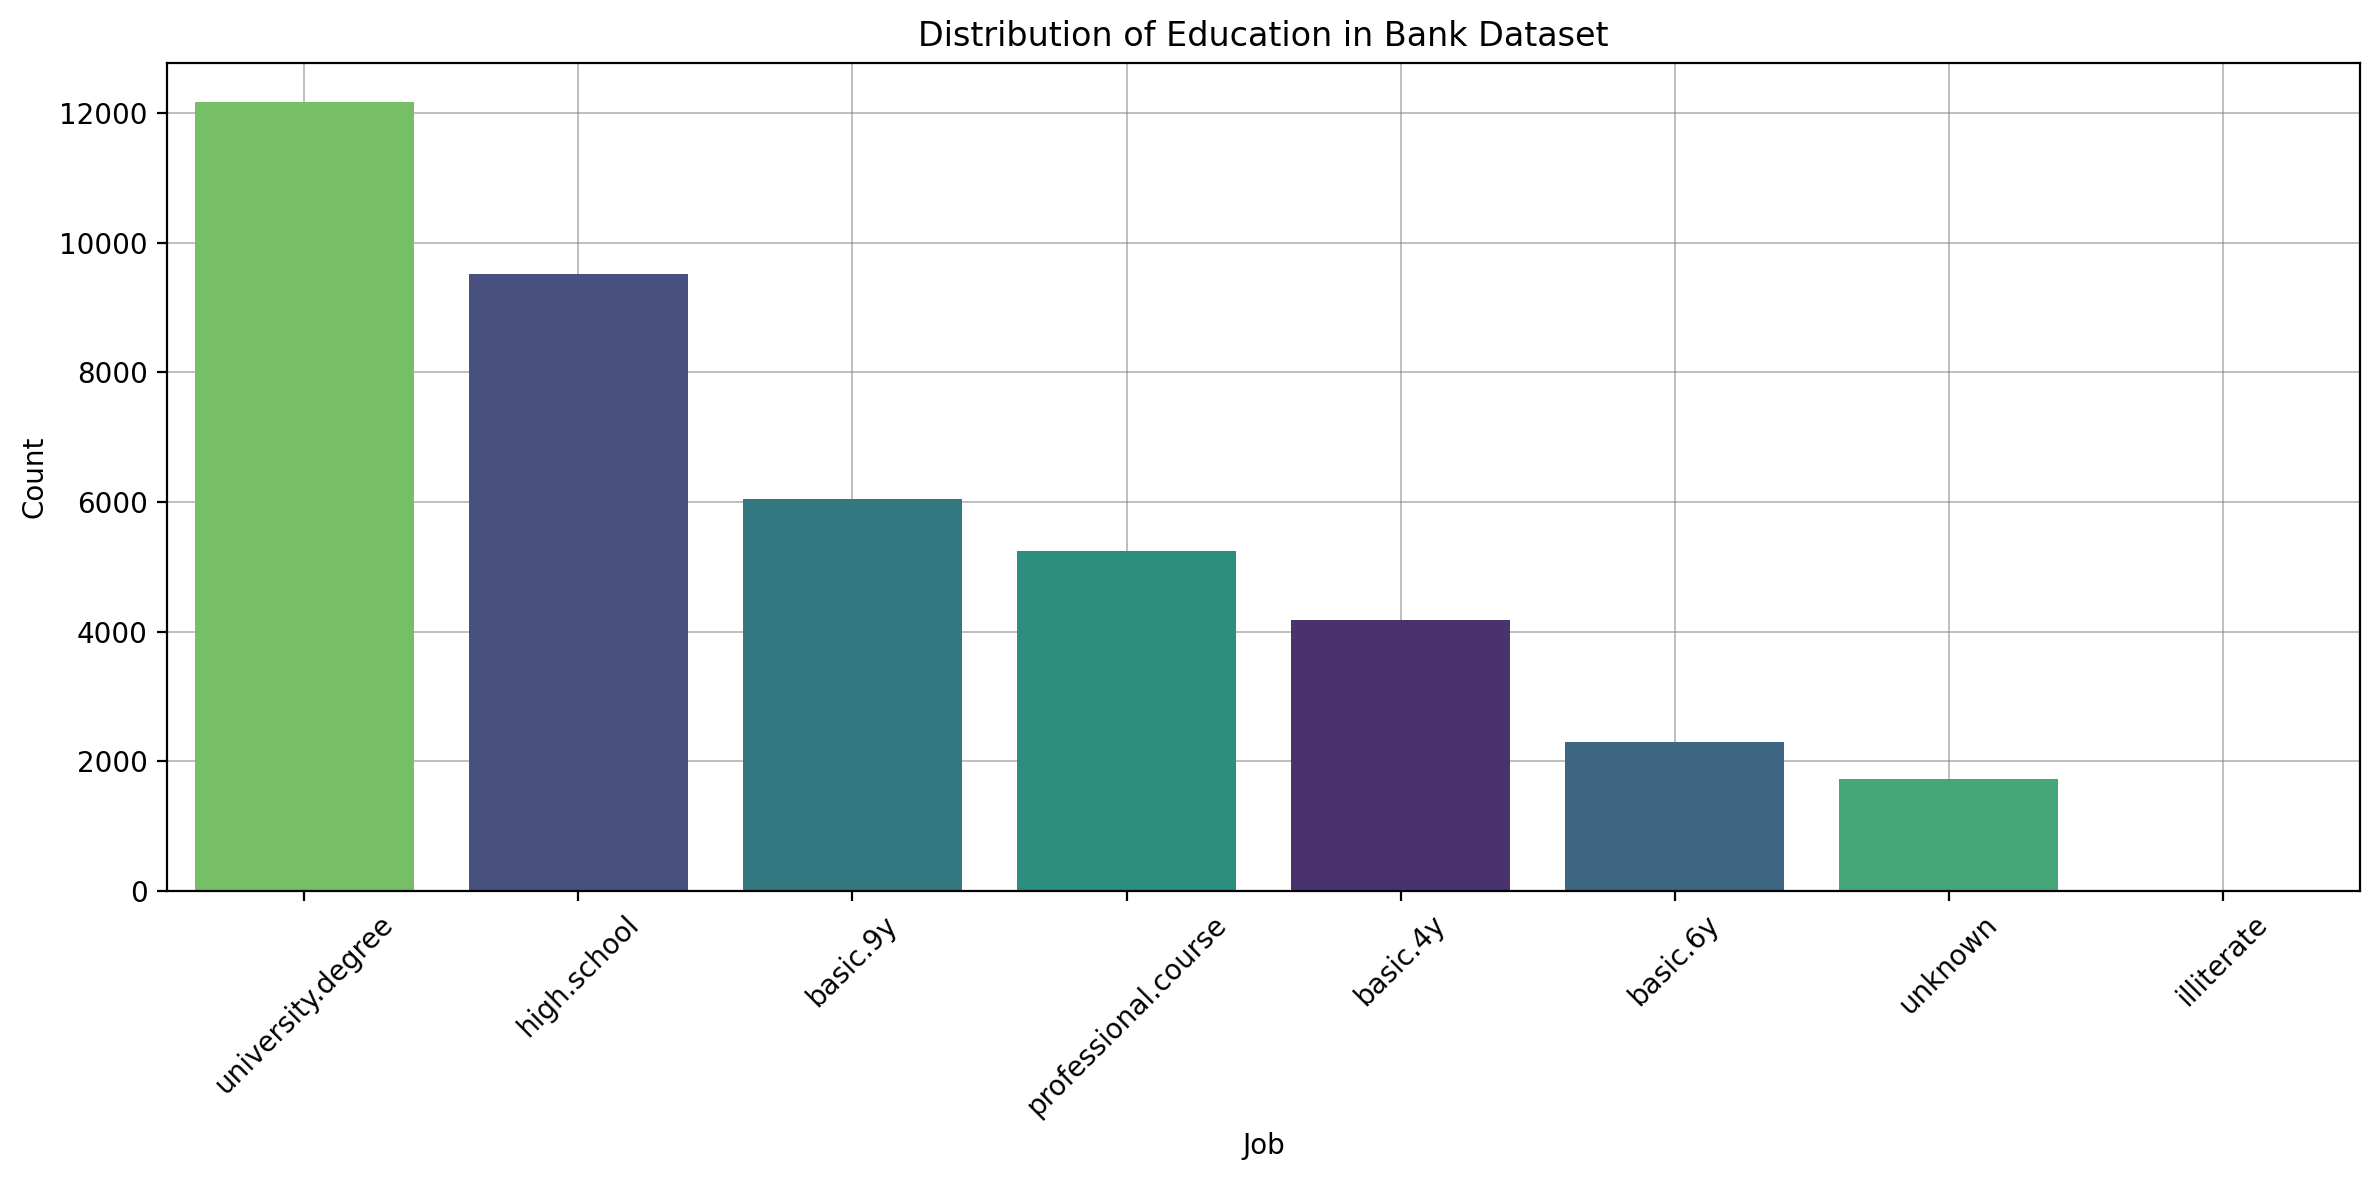

In [17]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
order = bank["education"].value_counts().index
sns.countplot(
    data=bank,
    x="education",
    order=bank["education"].value_counts().index,
    ax=ax,
    hue="education",
    palette="viridis",
)
ax.set(xlabel="Job", ylabel="Count", title="Distribution of Education in Bank Dataset")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [18]:
X = pd.get_dummies(bank)

In [19]:
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_X = scaler.fit_transform(X)

In [21]:
from sklearn.cluster import KMeans

display(help(KMeans))

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall ine

None

In [22]:
kmeans = KMeans(n_clusters=2)

cluster_labels = kmeans.fit_predict(scaled_X)

In [23]:
print(cluster_labels)

[1 1 1 ... 0 0 0]


In [24]:
X["Cluster"] = cluster_labels

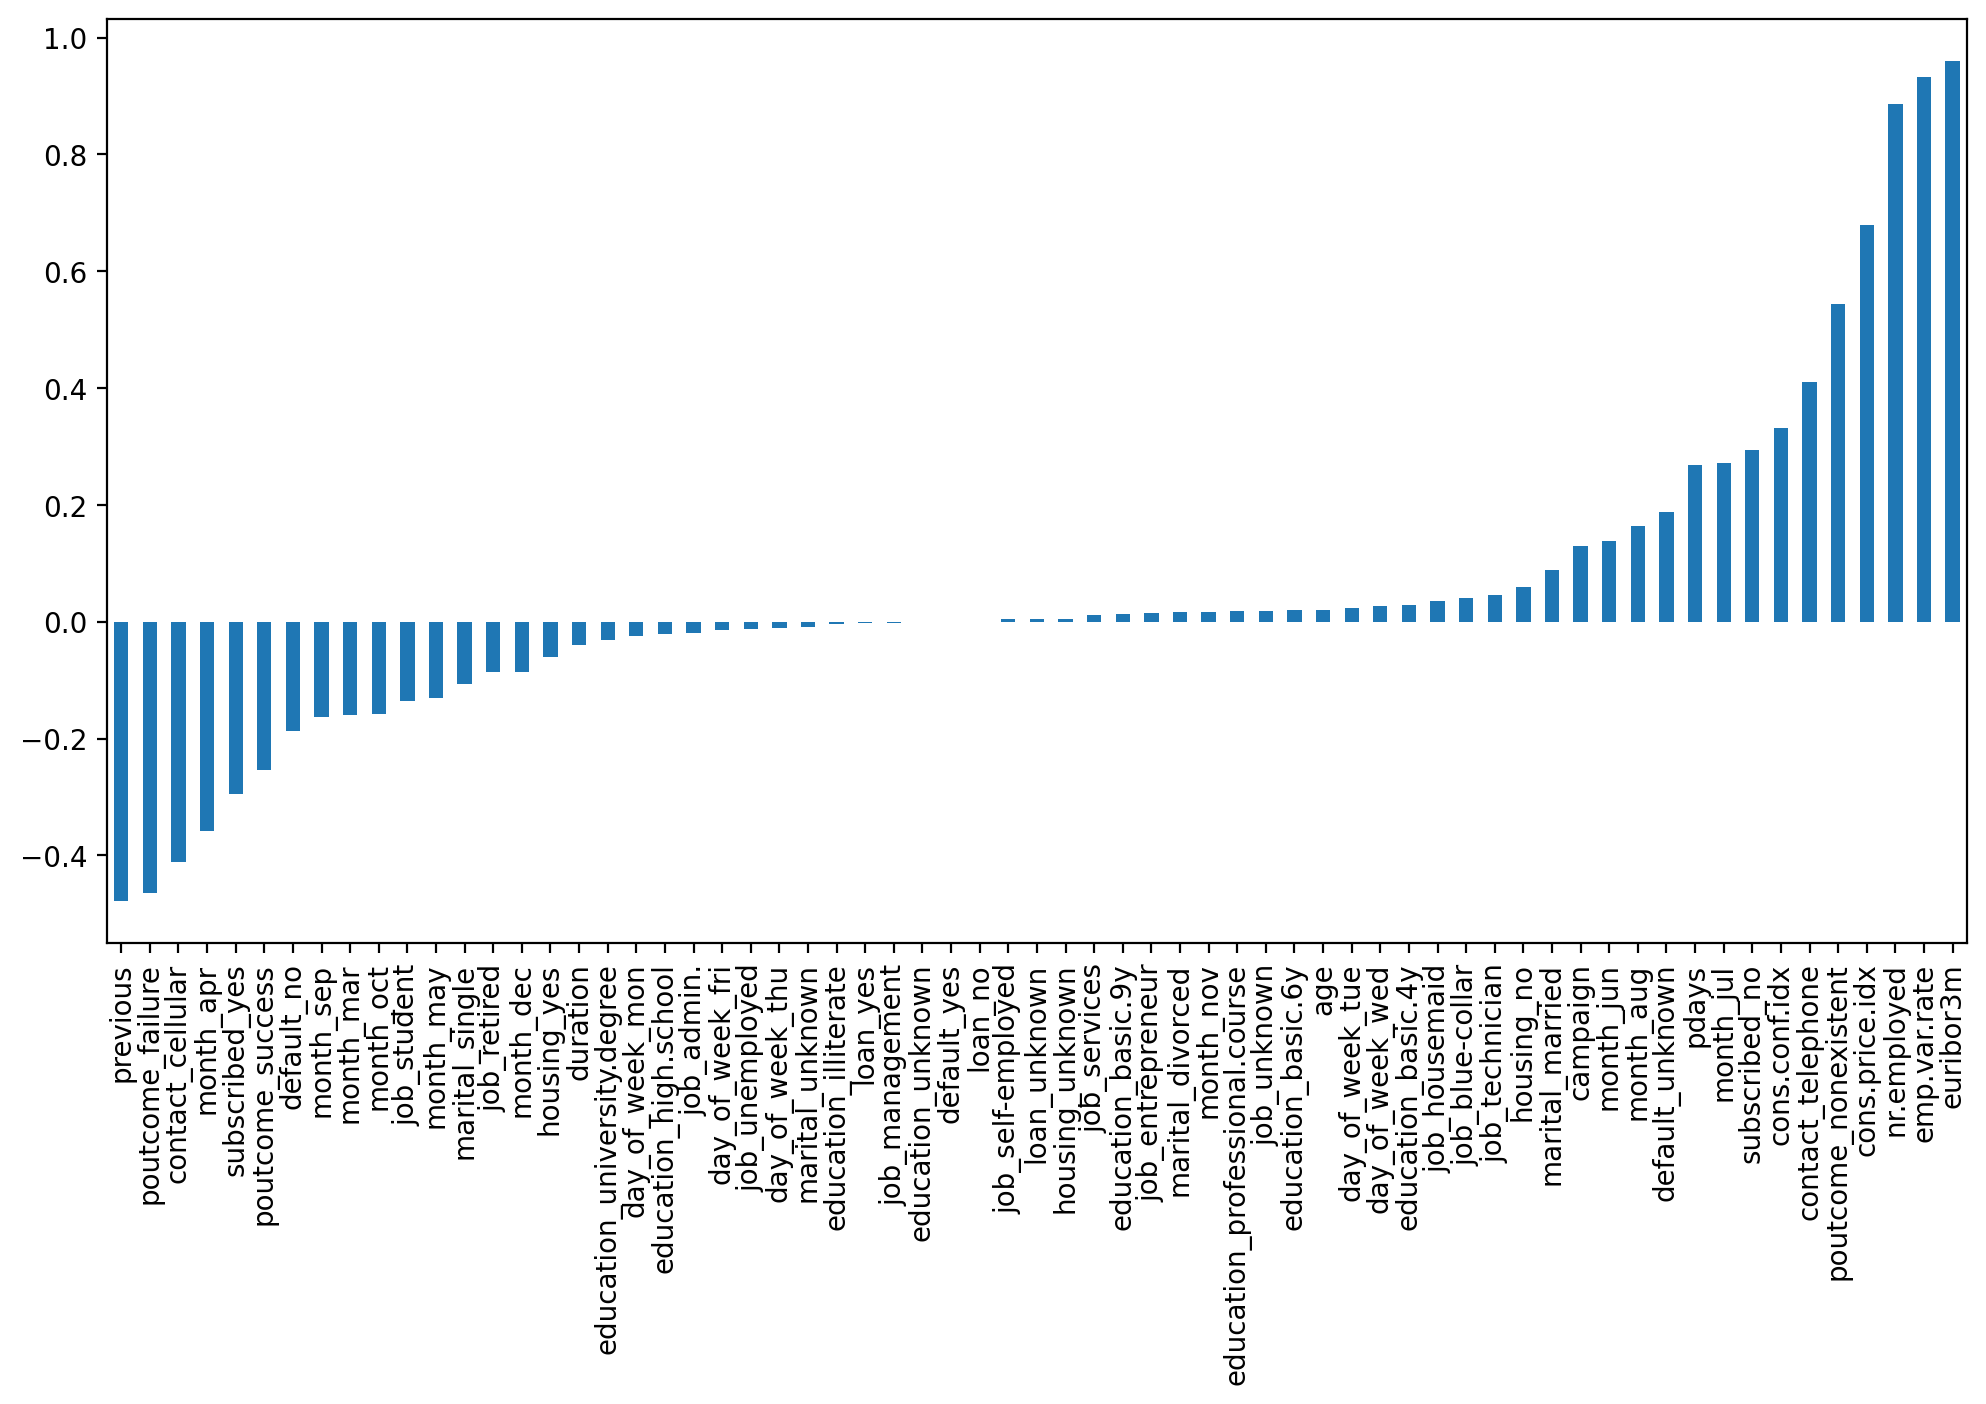

In [25]:
plt.figure(figsize=(12, 6), dpi=200)
X.corr()["Cluster"].iloc[:-1].sort_values().plot(kind="bar")
plt.show()

In [26]:
ssd = [KMeans(n_clusters=k).fit(scaled_X).inertia_ for k in np.arange(2, 10)]

In [27]:
ssd

[2469792.3673020783,
 2384150.263734195,
 2271503.599440176,
 2254116.723855706,
 2193388.23749258,
 2146185.8543066434,
 2107049.943532655,
 2012115.9276320115]

<function matplotlib.pyplot.show(close=None, block=None)>

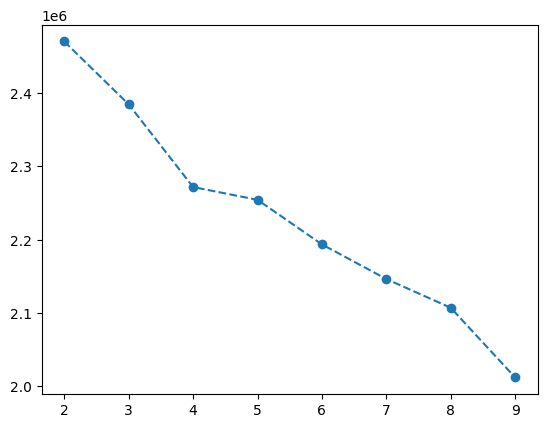

In [28]:
plt.plot(np.arange(2, 10), ssd, "o--")
plt.show

In [29]:
pd.Series(ssd).diff()

0              NaN
1    -85642.103568
2   -112646.664294
3    -17386.875584
4    -60728.486363
5    -47202.383186
6    -39135.910774
7    -94934.015901
dtype: float64

**Evaluating a clustering involves assessing its quality, either by comparing the discovered clusters to known ground truth labels using a cross-tabulation or, more commonly, by using an intrinsic metric like inertia to measure the compactness of the clusters. This intrinsic measure is crucial for guiding the selection of the optimal number of clusters via techniques like the elbow method.**

## The Two Paradigms of Cluster Evaluation

Once a clustering algorithm has partitioned the data, you need to determine how "good" the result is. This evaluation can be approached in two ways, depending on whether you have access to the "correct" answers.

1.  **Extrinsic Evaluation**: This is possible only when you have ground truth labels for your data (e.g., the actual species for the Iris flowers). You can then compare the algorithm's cluster assignments to these true labels to see how well they align. This is a measure of how accurately the clustering has recovered a known underlying structure.

2.  **Intrinsic Evaluation**: This is the more common scenario in unsupervised learning, where no ground truth labels exist. The evaluation must be based solely on the structure of the data and the clusters themselves. Intrinsic metrics typically measure the **compactness** (how close points are within a cluster) and **separation** (how far apart different clusters are).

### Extrinsic Evaluation with Cross-Tabulation

When ground truth labels are available, a **cross-tabulation** (or contingency table) is an excellent tool for comparing the predicted cluster labels against the true labels. It shows the distribution of samples at the intersection of each cluster and each true category.

#### Example: Comparing Iris Clusters to True Species

Let's continue with the Iris dataset, where we have the true species. We can build a cross-tabulation to see how well our 3-cluster solution corresponds to the 3 actual species.



In [30]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load, scale, and cluster the Iris data
iris = load_iris()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(iris.data)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(features_scaled)

# 2. Create a DataFrame for comparison
comparison_df = pd.DataFrame(
    {"cluster_label": cluster_labels, "true_species": iris.target_names[iris.target]}
)

# 3. Generate the cross-tabulation
cross_tab = pd.crosstab(comparison_df["cluster_label"], comparison_df["true_species"])

print("Cross-Tabulation of Cluster Labels vs. True Species:")
display(cross_tab)

Cross-Tabulation of Cluster Labels vs. True Species:


true_species,setosa,versicolor,virginica
cluster_label,,,
0,0,46,50
1,33,0,0
2,17,4,0


This table is highly informative. We can see that Cluster 0 perfectly corresponds to the *setosa* species. Cluster 1 has captured almost all of the *versicolor* samples, and Cluster 2 has captured the majority of the *virginica* samples, with some known overlap between the two.



### Intrinsic Evaluation with Inertia and the Elbow Method

In most cases, we don't have true labels. We must rely on an intrinsic metric to guide us. For k-means, the most important metric is **inertia**.

**Inertia** is the sum of squared distances of each sample to its closest cluster centroid.
$$Inertia = \sum_{i=0}^{n} \min_{\mu_j \in C}(||x_i - \mu_j||^2)$$
where $\mu_j$ is the centroid for cluster $j$.

In simple terms, **inertia measures the internal cohesion or tightness of the clusters**. A lower inertia means the clusters are more compact and dense, which is generally better. The k-means algorithm itself tries to find centroids that minimise this value.

### Finding the Optimal Number of Clusters (`k`)

While lower inertia is better, the metric will *always* decrease as you add more clusters (`k`). A clustering where every point is its own cluster would have an inertia of zero but would be useless. The goal is to find a balance: a low inertia value with a reasonably small number of clusters.

The **Elbow Method** is a popular heuristic for finding this balance. The process involves:

1.  Running k-means for a range of different `k` values.
2.  Plotting `k` against the inertia for each run.
3.  Looking for an "elbow" in the plot—the point where the rate of decrease in inertia slows down dramatically. This point represents a good trade-off.

### Example: Generating an Elbow Plot

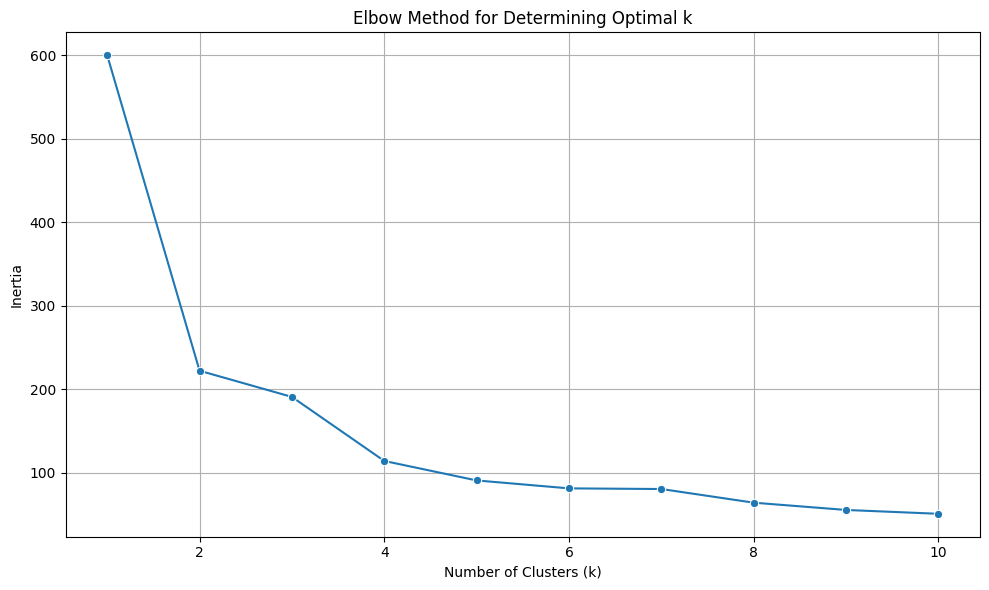

In [31]:
# Using the scaled Iris features from the previous example
k_range = range(1, 11)
inertia_values = []

# Run k-means for each value of k and store the inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(features_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=list(k_range), y=inertia_values, marker="o", ax=ax)
ax.set_title("Elbow Method for Determining Optimal k")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.grid(True)

plt.tight_layout()
plt.show()

The plot clearly shows that the inertia decreases sharply from k=1 to k=2, and again from k=2 to k=3. After k=3, the decrease becomes much more gradual. This distinct "elbow" at **k=3** suggests that it is the optimal number of clusters for the Iris dataset, which aligns with our extrinsic knowledge that there are three species.

In [32]:
seeds_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/machine_learning/unsupervised_learning_with_scikit-learn/data/seeds_dataset.txt"
seeds = pd.read_csv(seeds_url, sep=r"\s+", header=None)
seeds.head()

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [33]:
# create X by dropping column 7 (the target) from the seeds DataFrame
X = seeds.drop(columns=7)

# if you need a NumPy array for modeling:
X_values = X.values

# quick sanity check
X.shape

(210, 7)

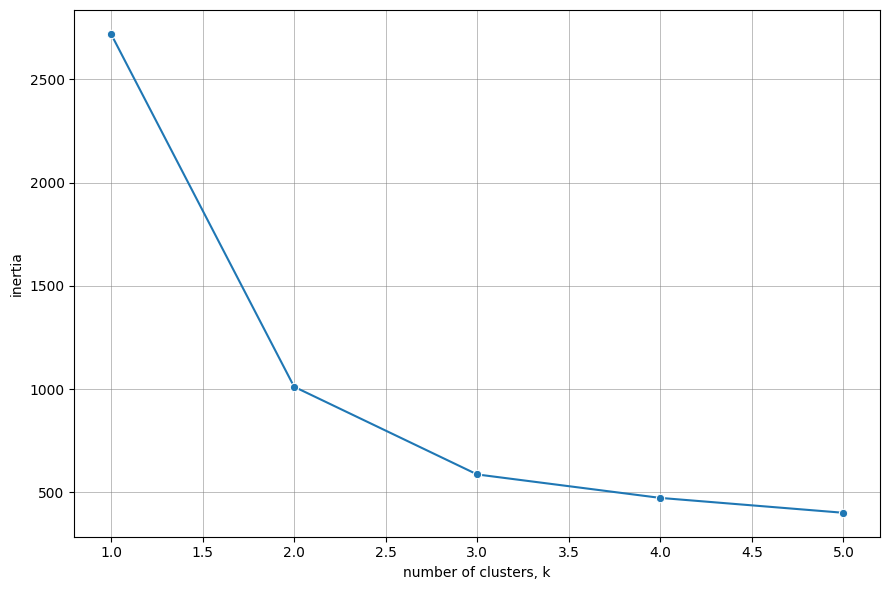

In [34]:
ks = range(1, 6)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)

    inertias.append(kmeans.inertia_)


# Plot ks vs inertias
fig, ax = plt.subplots(figsize=(9, 6))

sns.lineplot(x=ks, y=inertias, marker="o", ax=ax)
ax.set(xlabel="number of clusters, k", ylabel="inertia")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [35]:
from data.varieties import varieties

# Create a KMeans model with 3 clusters: model
kmeans = KMeans(n_clusters=3)

# Use fit_predict to fit model and obtain cluster labels: labels
labels = kmeans.fit_predict(X)

# Create a DataFrame with labels and varieties as columns: df
seeds_df = pd.DataFrame({"labels": labels, "varieties": varieties})

# Create crosstab: ct
ct = pd.crosstab(seeds_df["labels"], seeds_df["varieties"])

# Display ct
display(ct)

varieties,Canadian wheat,Kama wheat,Rosa wheat
labels,,,
0,2,60,10
1,0,1,60
2,68,9,0


**For distance-based algorithms like k-means, transforming features to have a uniform scale is a critical preprocessing step. Features with vastly different variances can disproportionately influence the clustering outcome, but this is easily corrected by standardizing the data, a process streamlined and made robust by using `scikit-learn` Pipelines.**

## The Problem of Disparate Feature Influence

The k-means algorithm works by minimizing the distance between data points and their assigned cluster centroids. This distance is typically the Euclidean distance, which is calculated across all features. A major pitfall arises when the features in the dataset have vastly different scales and variances.

Consider the Piedmont wines dataset, which includes features like `alcohol` content (low variance) and `proline` (extremely high variance). When k-means calculates distances, the `proline` feature, with its massive scale, will completely dominate the calculation. The algorithm will essentially only pay attention to grouping points based on `proline`, ignoring the subtle but important information in the other features. As a result, the clustering will be biased and will likely fail to uncover the true underlying structure of the data.

### Case Study: Clustering Wines Without Scaling

Let's demonstrate this problem by applying k-means directly to the raw, unscaled wine dataset. We know there are three varieties of wine, so we will ask the algorithm to find three clusters and then compare the result to the true labels using a cross-tabulation.





Clustering Results WITHOUT Scaling:
variety           class_0  class_1  class_2
cluster_unscaled                           
0                       1       64       37
1                      31        7       11
2                      27        0        0


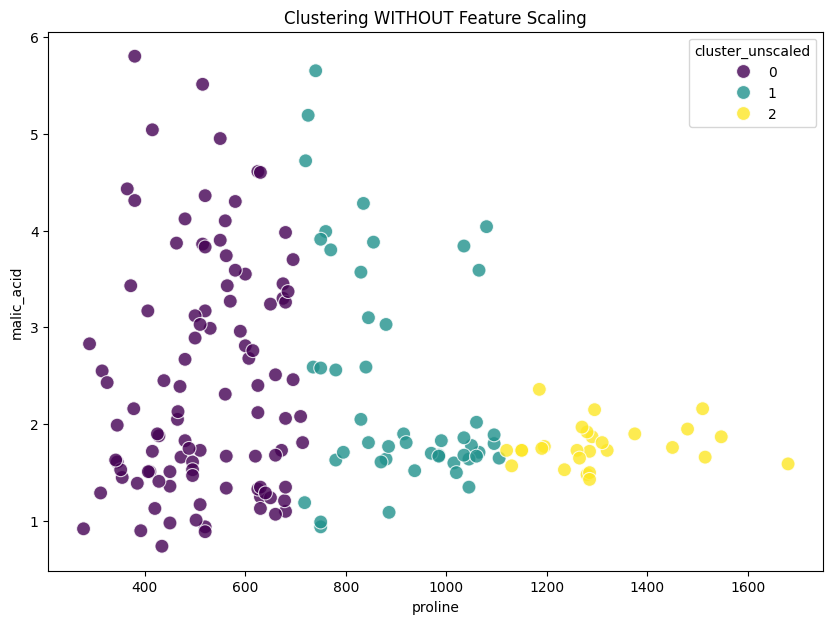

In [36]:
from sklearn.datasets import load_wine

# 1. Load the data
wine = load_wine()
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df["variety"] = [wine.target_names[i] for i in wine.target]

# 2. Apply k-Means directly to the unscaled data
kmeans_unscaled = KMeans(n_clusters=3, random_state=42, n_init="auto")
wine_df["cluster_unscaled"] = kmeans_unscaled.fit_predict(wine.data)

# 3. Evaluate with a cross-tabulation
cross_tab_unscaled = pd.crosstab(wine_df["cluster_unscaled"], wine_df["variety"])
print("Clustering Results WITHOUT Scaling:")
print(cross_tab_unscaled)

# 4. Visualise the poor clustering
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=wine_df,
    x="proline",
    y="malic_acid",
    hue="cluster_unscaled",
    palette="viridis",
    s=100,
    alpha=0.8,
    ax=ax,
)
ax.set_title("Clustering WITHOUT Feature Scaling")
plt.show()

The cross-tabulation shows that the clusters are a jumbled mix of the true wine varieties. Cluster 0, for instance, contains a significant number of samples from all three varieties. The scatter plot confirms that the clustering was dominated by the `proline` feature, effectively creating vertical bands with little regard for the other features.




### The Solution: Standardization and Pipelines

The solution is to give every feature equal influence by standardizing the data. We use `scikit-learn`'s `StandardScaler` to transform each feature to have a mean of 0 and a variance of 1.

The best practice for combining preprocessing steps (like scaling) with a model (like k-means) is to use a `Pipeline`. A **pipeline** chains these steps into a single object. When you call `.fit()` on the pipeline, it automatically fits the scaler and then fits k-means on the scaled data. This is convenient, clean, and prevents common errors.


### Case Study: Clustering Wines With Scaling via a Pipeline

Now, let's repeat the process correctly using a pipeline to first scale the data and then apply k-means.


Clustering Results WITH Scaling:
variety         class_0  class_1  class_2
cluster_scaled                           
0                     0       65        0
1                     0        3       48
2                    59        3        0


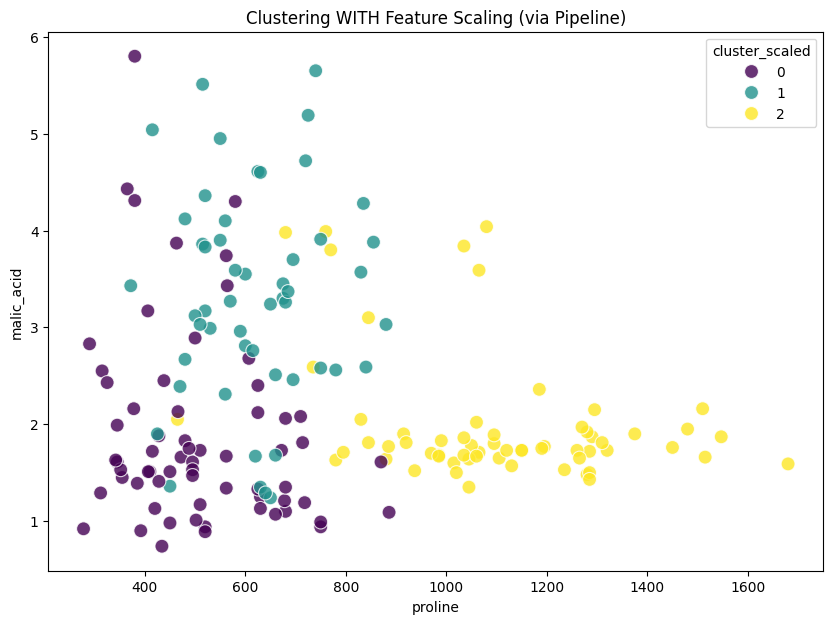

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Create a pipeline that first scales, then clusters
pipeline = make_pipeline(
    StandardScaler(), KMeans(n_clusters=3, random_state=42, n_init="auto")
)

# 2. Fit the pipeline to the data and get new labels
wine_df["cluster_scaled"] = pipeline.fit_predict(wine.data)

# 3. Evaluate the new clustering with a cross-tabulation
cross_tab_scaled = pd.crosstab(wine_df["cluster_scaled"], wine_df["variety"])
print("Clustering Results WITH Scaling:")
print(cross_tab_scaled)

# 4. Visualise the improved clustering
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=wine_df,
    x="proline",
    y="malic_acid",
    hue="cluster_scaled",  # Colour by the new, improved cluster labels
    palette="viridis",
    s=100,
    alpha=0.8,
    ax=ax,
)
ax.set_title("Clustering WITH Feature Scaling (via Pipeline)")
plt.show()

The results are dramatically better. The cross-tabulation shows a nearly perfect correspondence between the clusters and the true wine varieties. The new scatter plot, colored by these improved labels, reveals a much more meaningful and accurate grouping of the data points. This demonstrates unequivocally that for distance-based algorithms like k-means, **feature scaling is not optional—it is a mandatory step for achieving a meaningful result.**

In [38]:
# Perform the necessary imports
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create an instance of StandardScaler called scaler.
scaler = StandardScaler()

# Create an instance of KMeans with 4 clusters called kmeans.
kmeans = KMeans(n_clusters=4)

# Create a pipeline called pipeline that chains scaler and kmeans.
pipeline = make_pipeline(scaler, kmeans)

In [39]:
from data.samples import samples, species

pipeline.fit(samples)

# Calculate the cluster labels: labels
labels = pipeline.predict(samples)

# Create a DataFrame with labels and species as columns: df
df = pd.DataFrame(data={"labels": labels, "species": species})
# Using pd.crosstab(), create a cross-tabulation ct of df['labels'] and df['species']
ct = pd.crosstab(df["labels"], df["species"])

display(ct)

species,Bream,Pike,Roach,Smelt
labels,,,,
0,1,0,19,1
1,0,17,0,0
2,33,0,1,0
3,0,0,0,13


In [40]:
movements_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/machine_learning/unsupervised_learning_with_scikit-learn/data/movements.csv"
movements = pd.read_csv(
    movements_url, usecols=lambda col: not col.startswith("Unnamed")
)

In [41]:
# Import Normalizer
from sklearn.preprocessing import Normalizer

# Create a normalizer: normalizer
normalizer = Normalizer()

# Create a KMeans model with 10 clusters: kmeans
kmeans = KMeans(n_clusters=10)

# Make a pipeline chaining normalizer and kmeans: pipeline
pipeline = make_pipeline(normalizer, kmeans)

# Fit pipeline to the daily price movements
pipeline.fit(movements)

,steps,"[('normalizer', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,norm,'l2'
,copy,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001


In [42]:
from data.companies import companies

# Predict the cluster labels: labels
labels = pipeline.predict(movements)

labels_df = pd.DataFrame(data={"labels": labels, "companies": companies})

display(labels_df.sort_values(by="labels"))

,labels,companies
0,0,Apple
11,0,Cisco
14,0,Dell
33,0,Microsoft
8,1,Caterpillar
30,1,MasterCard
32,1,3M
13,1,DuPont de Nemours
53,1,Valero Energy
35,1,Navistar


**Hierarchical clustering is an unsupervised learning method that builds a nested hierarchy of clusters, revealing relationships between data points at multiple levels of similarity. This hierarchy is visualized using a tree-like diagram called a dendrogram, which can be generated in Python using the SciPy library.**


### Understanding Hierarchical Clustering

Unlike k-means, which produces a single, flat partition of the data for a pre-specified number of clusters `k`, hierarchical clustering builds a complete, multi-level structure of how data points group together. This is particularly useful for visualising data and understanding its intrinsic structure without having to choose the number of clusters beforehand.

The most common approach is **agglomerative ("bottom-up") clustering**, which follows a simple, iterative process:

1.  **Initialisation**: Each data point begins in its own, single-member cluster.
2.  **Iteration**: At each step, the two *closest* or most similar clusters are identified and merged into a new, larger cluster.
3.  **Termination**: This process repeats until all data points have been merged into a single, all-encompassing cluster.

The entire history of these merges is what forms the hierarchy. A key parameter in this process is the **linkage method**, which defines how the "distance" between two clusters is calculated. Common methods include:

  - **`'complete'`**: The distance is the maximum distance between any sample in the first cluster and any sample in the second cluster.
  - **`'single'`**: The distance is the minimum distance between any sample in the first cluster and any sample in the second cluster.
  - **`'ward'`**: This method merges the two clusters that result in the minimum increase in the total within-cluster variance. It is a robust default choice that often produces well-balanced clusters.

### How to Read a Dendrogram

The dendrogram is the signature visualisation of hierarchical clustering. It is a tree diagram that illustrates every merge step performed by the algorithm.

To interpret it correctly, read it from the bottom up:

  - **The Leaves (Bottom)**: Each label on the x-axis represents an individual data point (a sample).
  - **The Branches (Vertical Lines)**: Each vertical line represents a cluster. Its length indicates the dissimilarity within that cluster.
  - **The Merges (Horizontal Lines)**: A horizontal line connects two vertical lines, signifying that those two clusters have been merged.
  - **The Y-Axis (Height)**: The height of the horizontal line indicates the **dissimilarity** or **distance** at which the two clusters were merged. A merge that happens high up the diagram means two very dissimilar clusters were joined together. A merge that happens low down means two very similar clusters were joined.

By observing the heights of the merges, you can gain an intuitive understanding of the data's structure and even decide on a natural number of clusters by "cutting" the dendrogram at a certain height.

### A Complete Practical Example with SciPy

While `scikit-learn` has an implementation of agglomerative clustering, the classic and most powerful tools for performing the clustering and visualising the dendrogram are found in the `scipy` library.

Let's perform a hierarchical clustering on a simplified version of the Eurovision 2016 voting dataset.




In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Create a sample dataset and country names
# Rows are countries (samples), columns are scores given to songs (features)
np.random.seed(42)
country_names = [
    "Sweden",
    "Denmark",
    "Norway",
    "Finland",  # Nordic block
    "Spain",
    "Portugal",
    "Italy",  # Southern block
    "Germany",
    "Austria",
]  # Central block

# Create some voting patterns
nordic_votes = np.random.rand(4, 10) * 5 + 5  # High scores
southern_votes = np.random.rand(3, 10) * 5 + 2  # Medium scores
central_votes = np.random.rand(2, 10) * 3  # Low scores

scores = np.vstack([nordic_votes, southern_votes, central_votes])
scores_df = pd.DataFrame(scores, index=country_names)

# 2. Perform Hierarchical Clustering using the 'ward' linkage method
# The linkage function returns a matrix that encodes the cluster merges
mergings = linkage(scores, method="ward")

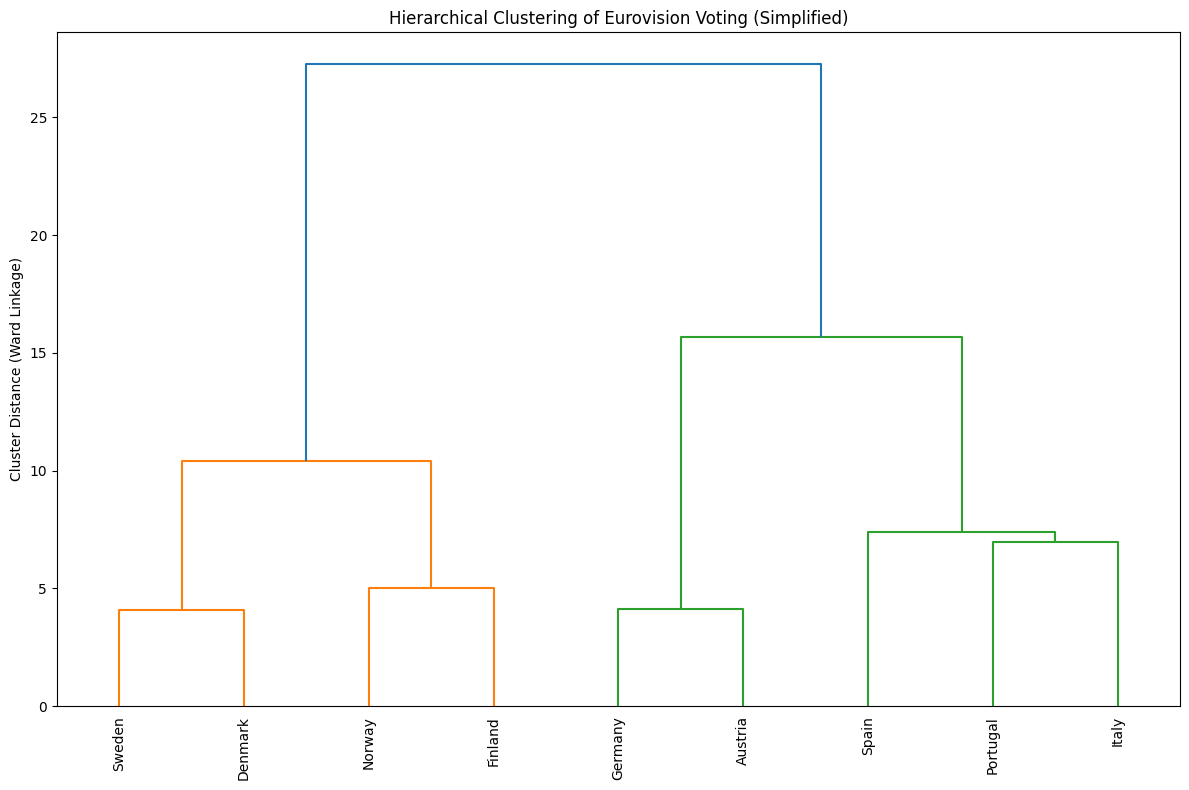

In [44]:
# 3. Plot the Dendrogram
# We use a matplotlib Axes object for an OOP approach
fig, ax = plt.subplots(figsize=(12, 8))

dendrogram(mergings, labels=country_names, leaf_rotation=90, leaf_font_size=10, ax=ax)

ax.set_title("Hierarchical Clustering of Eurovision Voting (Simplified)")
ax.set_ylabel("Cluster Distance (Ward Linkage)")
plt.tight_layout()
plt.show()

The resulting dendrogram clearly visualises the clustering process. It correctly identifies the distinct voting blocs we created in our synthetic data. For example, 'Sweden', 'Denmark', 'Norway', and 'Finland' are all merged together at a low distance, indicating their high similarity, before this "Nordic" cluster is eventually merged with the others at a much higher distance.

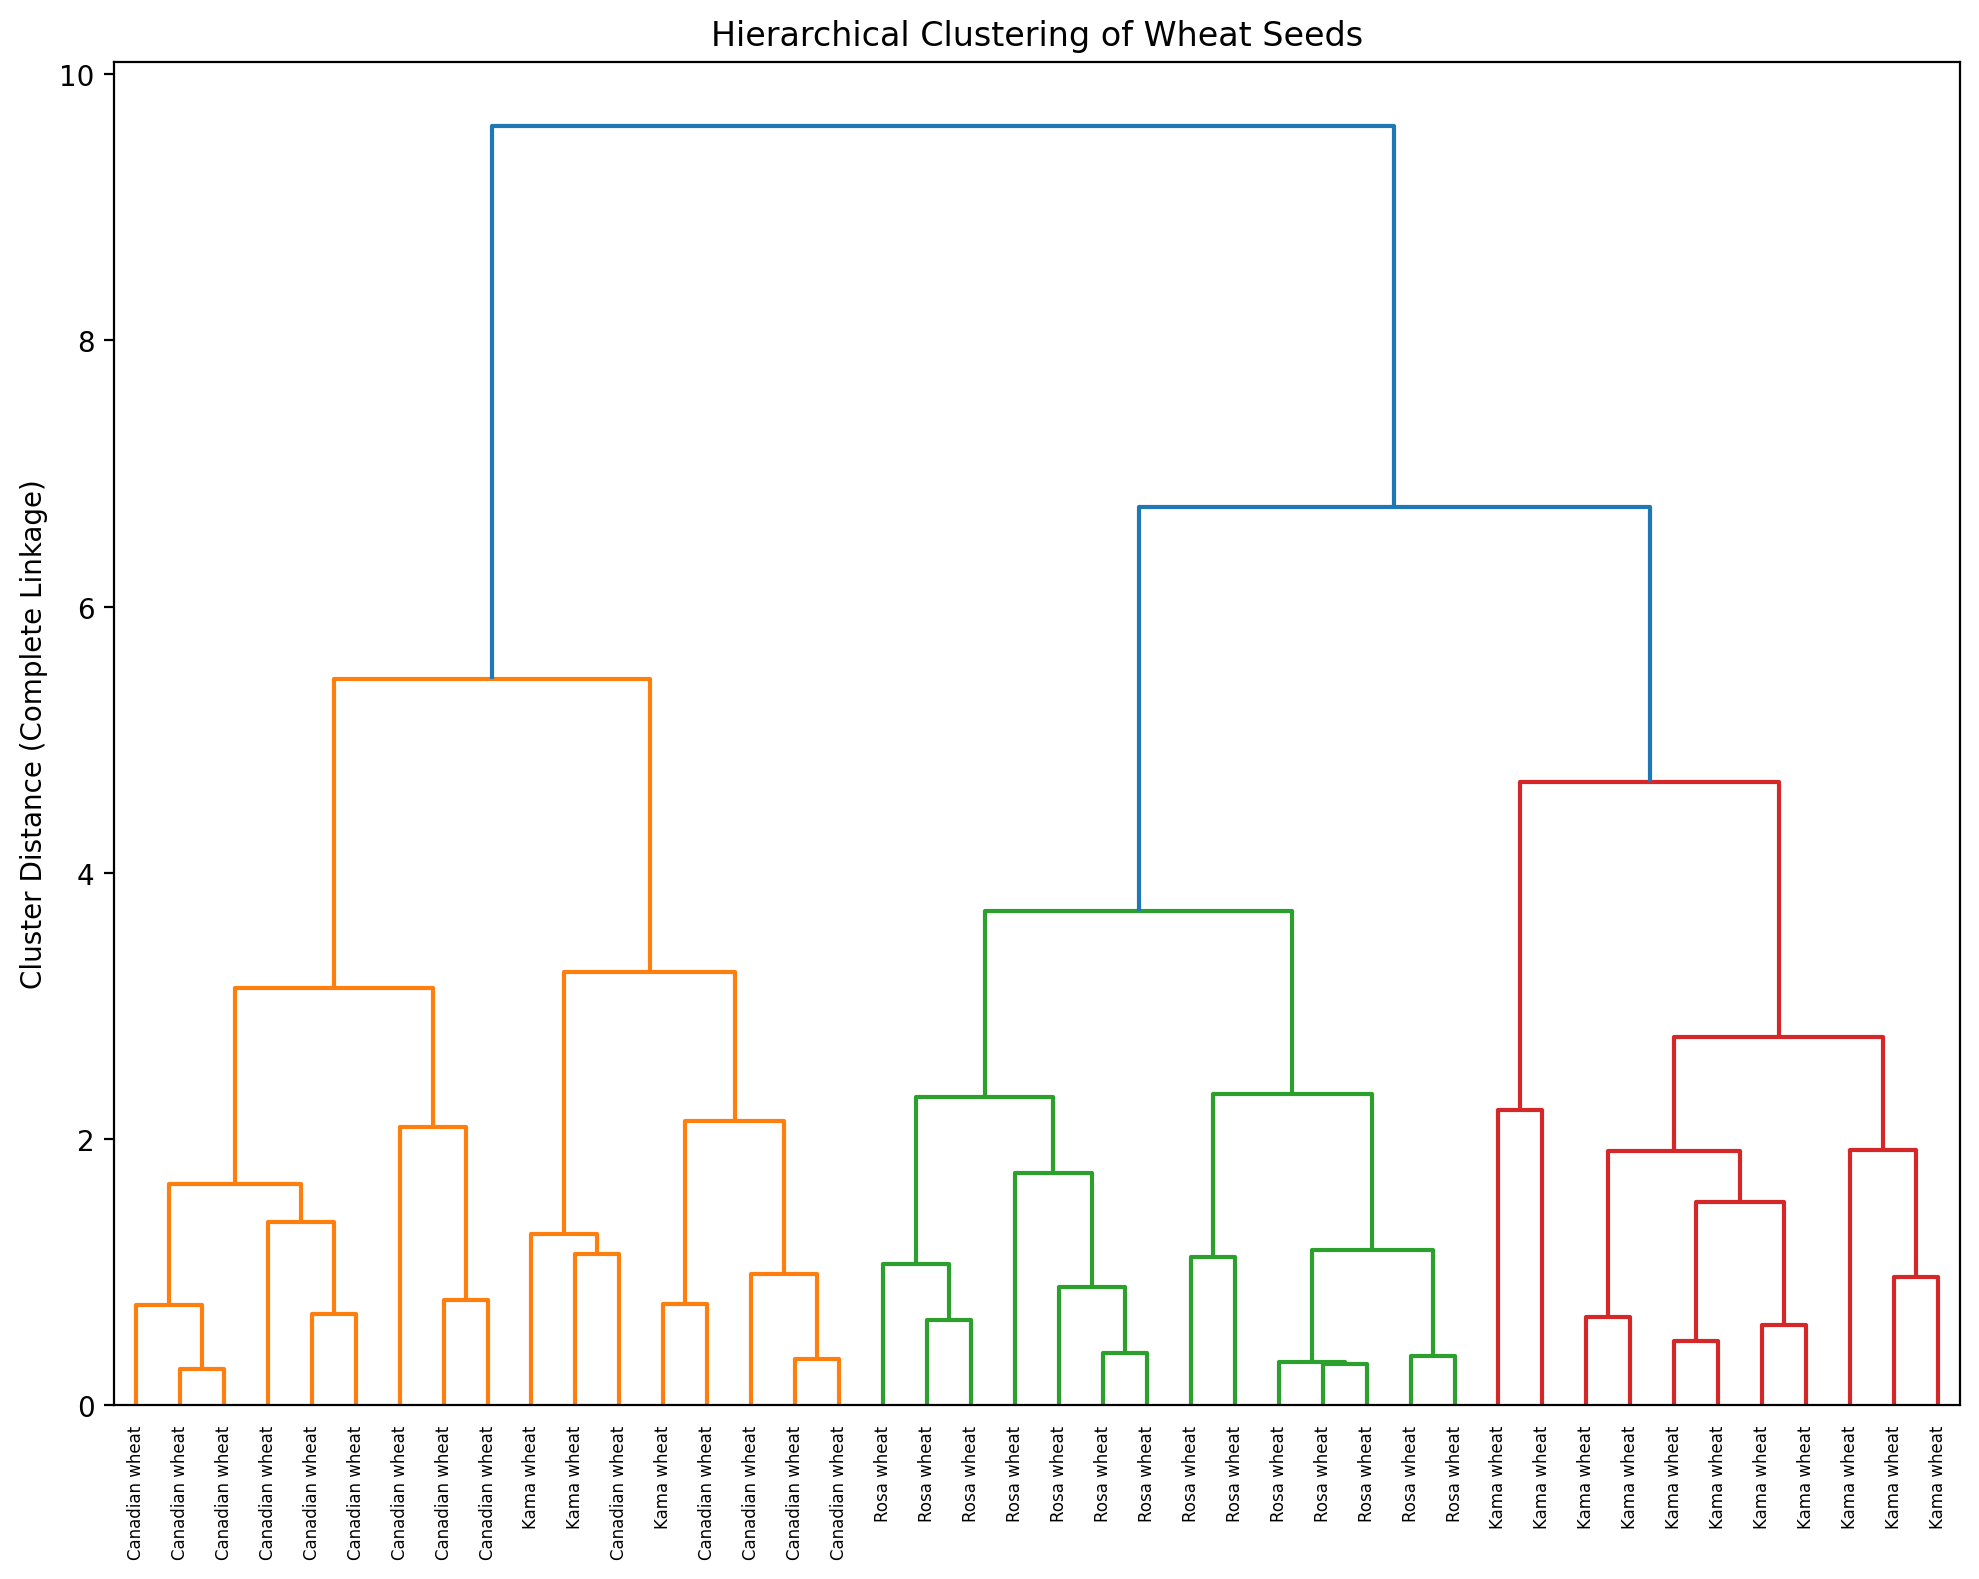

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram
from data.samples_2 import samples_2, varieties_2

# Calculate the linkage: mergings
mergings = linkage(samples_2, method="complete")

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# Plot the dendrogram, using varieties as labels
dendrogram(mergings, labels=varieties_2, leaf_rotation=90, leaf_font_size=6, ax=ax)
ax.set_title("Hierarchical Clustering of Wheat Seeds")
ax.set_ylabel("Cluster Distance (Complete Linkage)")
plt.tight_layout()
plt.show()

In [46]:
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

# Load stock movement data; index_col=0 sets the first column as row labels (company names)
movements_2_url = (
    "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/"
    "refs/heads/main/Python/machine_learning/unsupervised_learning_with_scikit-learn/"
    "data/movements_2.csv"
)
df = pd.read_csv(movements_2_url, index_col=0)

# Extract company names as labels for the dendrogram; assumes 'movements' DataFrame exists from prior cells
labels = movements.index.tolist()

# Compute pairwise distances using correlation metric: measures similarity in stock price movements (1 - correlation coefficient)
pairwise_dist = pdist(movements.values, metric="correlation")

# Perform hierarchical clustering with complete linkage: merges clusters based on maximum distance between points, avoiding chaining issues
Z = linkage(
    pairwise_dist, method="complete"
)  # Alternative: method='average' for mean distance merging

# Calculate cophenetic correlation: measures how well the dendrogram preserves original pairwise distances (closer to 1 is better)
coph_corr, _ = cophenet(Z, pairwise_dist)
print(f"Cophenetic correlation (higher preserves distances better): {coph_corr:.3f}")

Cophenetic correlation (higher preserves distances better): 0.541


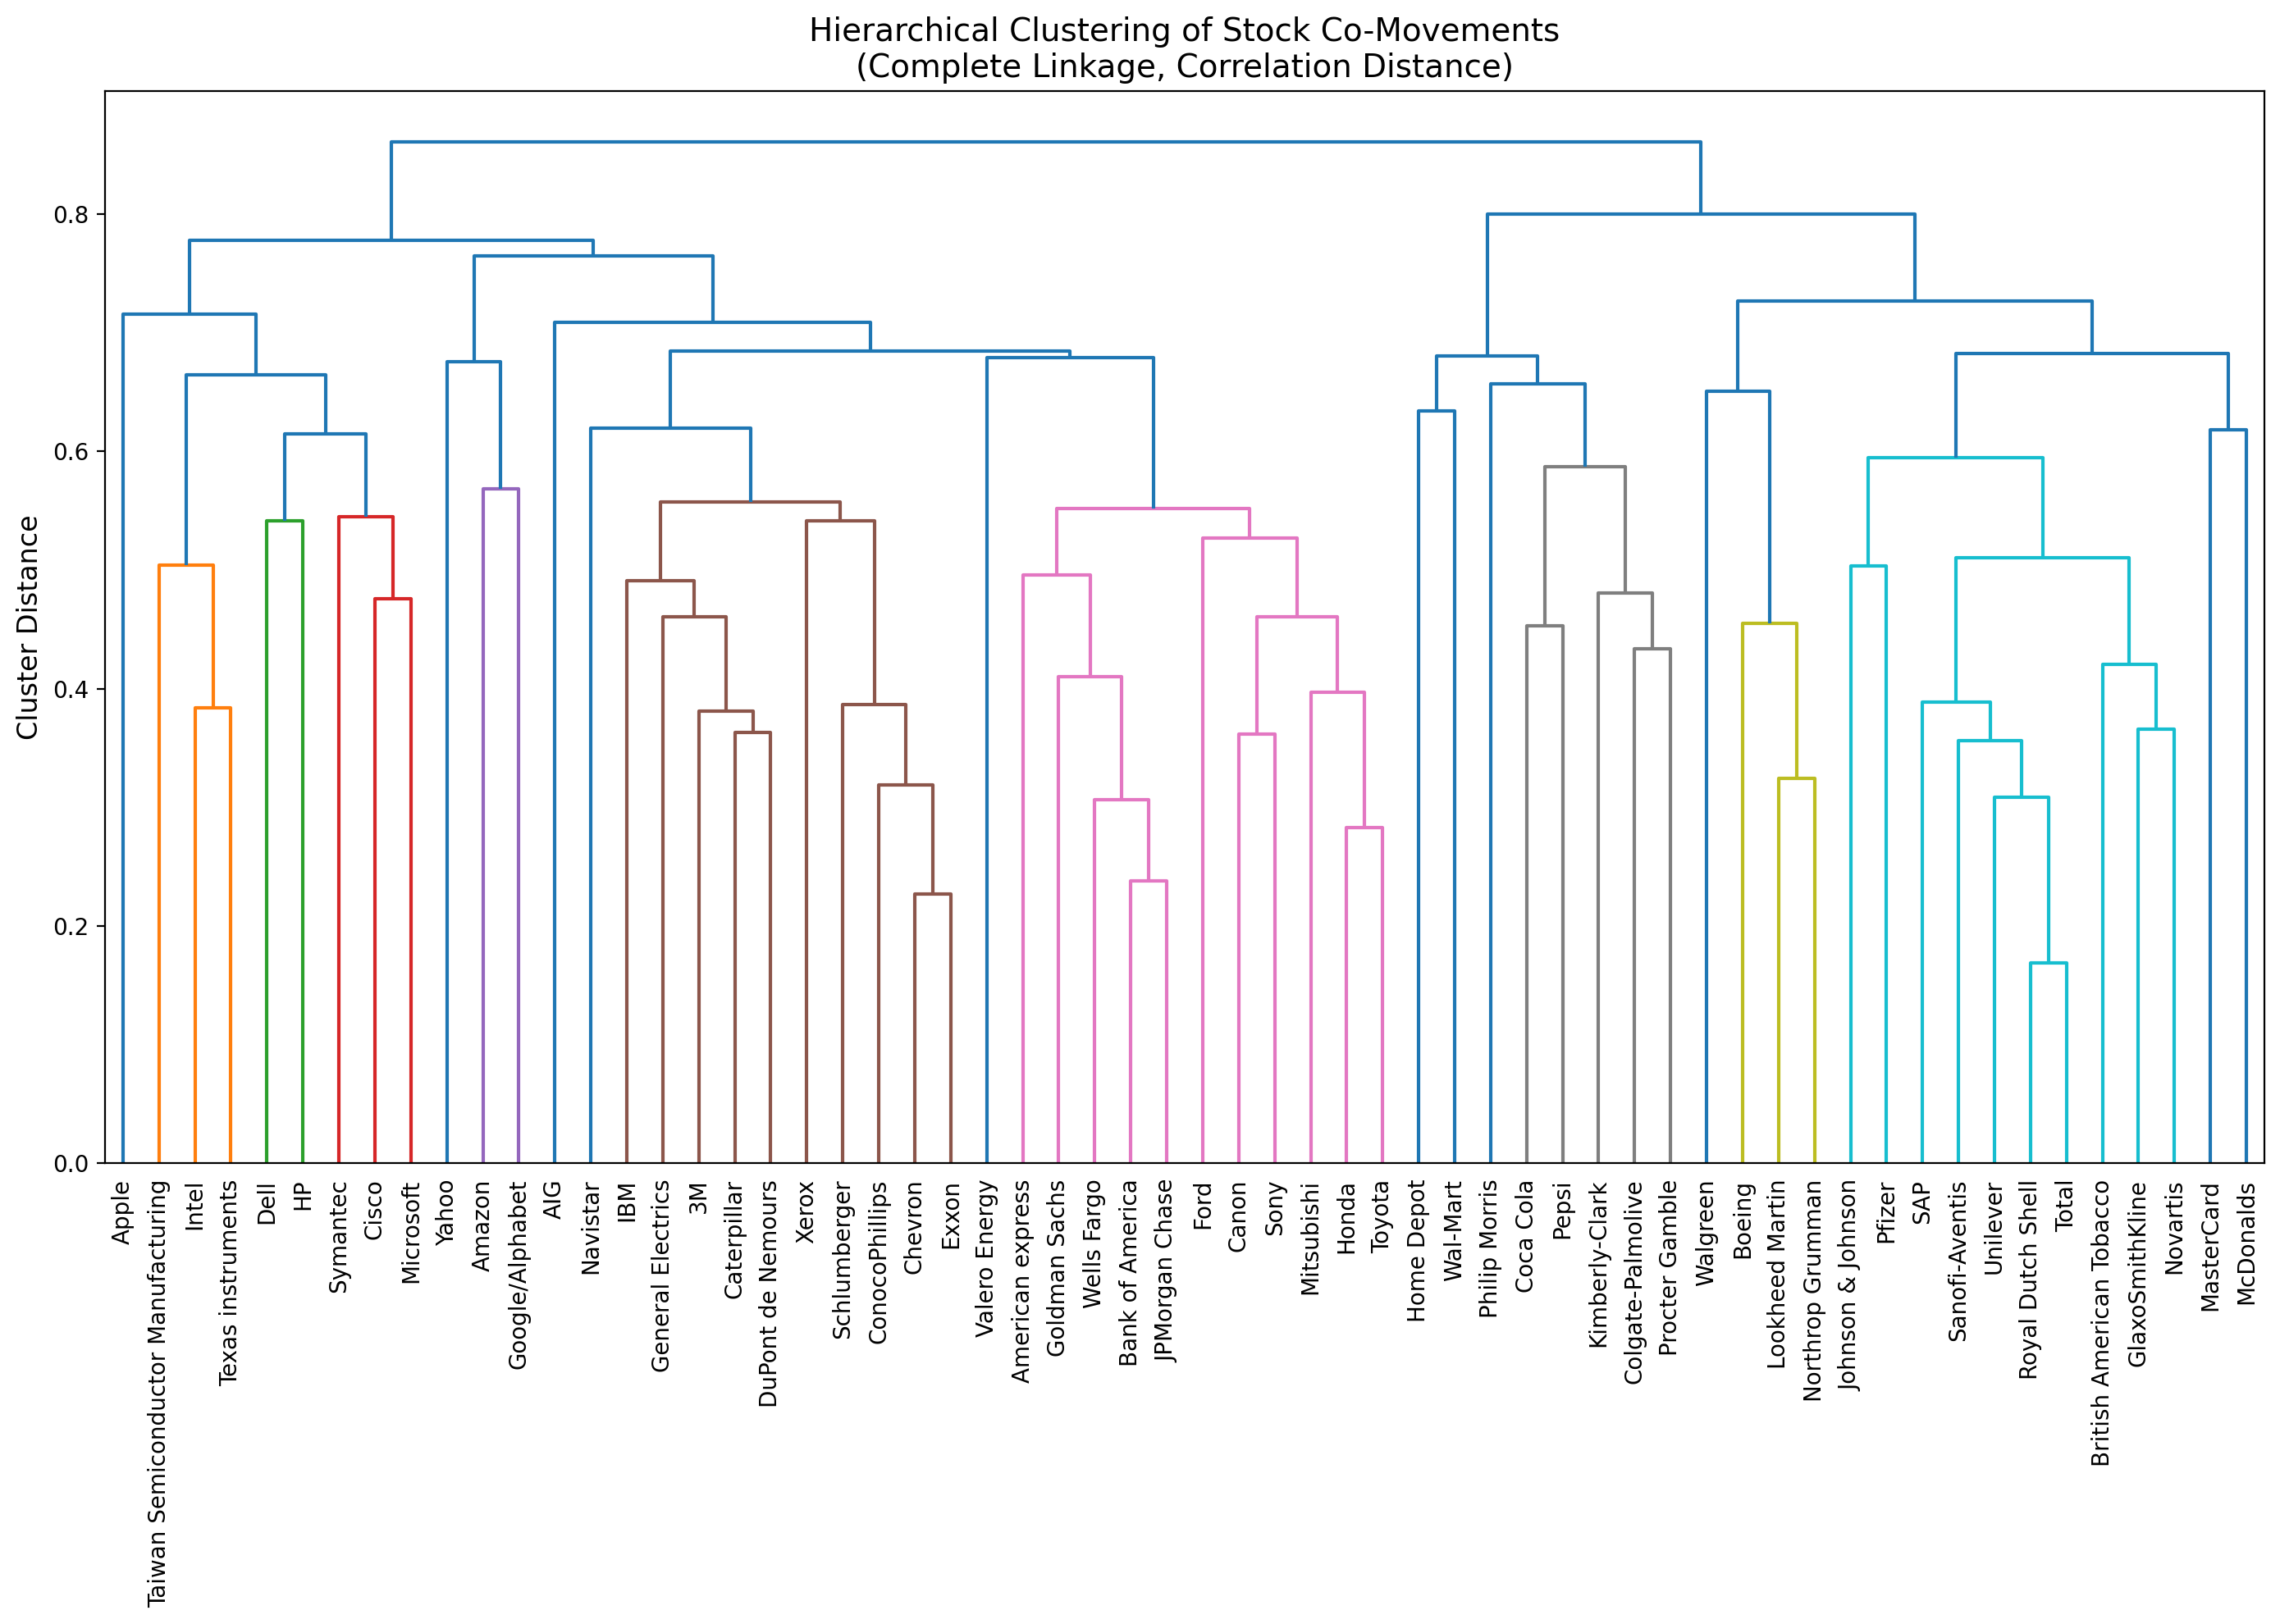

In [47]:
fig, ax = plt.subplots(figsize=(14, 10), dpi=200)

dendrogram(Z, labels=companies, leaf_rotation=90, leaf_font_size=10, ax=ax)

ax.set_title(
    "Hierarchical Clustering of Stock Co-Movements\n(Complete Linkage, Correlation Distance)",
    fontsize=14,
)

ax.set_ylabel("Cluster Distance", fontsize=12)

plt.tight_layout()
plt.show()

**Flat cluster labels can be extracted from a hierarchical clustering by "cutting" the dendrogram at a specific height, which corresponds to a distance threshold. This process, performed in Python using SciPy's `fcluster` function, transforms the nested hierarchy into a single, practical partition of the data, similar to the output of a k-means analysis.**


### From Hierarchy to a Flat Clustering

While a dendrogram provides a rich visualisation of the entire cluster hierarchy, many practical applications require a single, definitive grouping of the data—a "flat" set of cluster labels. For example, you might need to assign each customer to one of three market segments. Hierarchical clustering can produce this by specifying an intermediate stage of the clustering process.

The most intuitive way to think about this is to imagine drawing a horizontal line across a dendrogram at a chosen height. The number of distinct clusters in the resulting flat partition is equal to the number of vertical lines the horizontal line intersects. Any merges that occurred *below* this line are preserved, while any merges that would have occurred *above* it are ignored.

The height of this "cut" corresponds to a **distance threshold**. You are effectively telling the algorithm to form clusters such that the dissimilarity *within* any given cluster is less than your threshold.

### The Role of the Distance Criterion

The `fcluster` function in `scipy.cluster.hierarchy` is the tool for extracting these flat labels. It takes the linkage matrix (the output of the `linkage` function) and a criterion for forming the clusters. The two most important criteria are:

1.  **`criterion='distance'`**: You provide a distance threshold, `t`. `fcluster` will form clusters where the distance between any two original samples in the same flat cluster is at most `t`. This directly corresponds to the height at which you "cut" the dendrogram.
2.  **`criterion='maxclust'`**: You provide a target number of clusters, `k`. `fcluster` will find the lowest possible distance threshold that results in exactly `k` clusters. This is very useful when you have a specific number of groups in mind.

Remember, the meaning of "distance" is determined by the **linkage method** (e.g., `'ward'`, `'complete'`) you chose when you first performed the clustering with the `linkage` function.

### A Complete Practical Example

Let's use our simplified Eurovision dataset to demonstrate how to generate a dendrogram, visualise a cut, and extract the corresponding cluster labels.

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. Use the same sample data from the previous guide
np.random.seed(42)
country_names = [
    "Sweden",
    "Denmark",
    "Norway",
    "Finland",
    "Spain",
    "Portugal",
    "Italy",
    "Germany",
    "Austria",
]
nordic_votes = np.random.rand(4, 10) * 5 + 5
southern_votes = np.random.rand(3, 10) * 5 + 2
central_votes = np.random.rand(2, 10) * 3
scores = np.vstack([nordic_votes, southern_votes, central_votes])

# 2. Perform hierarchical clustering
mergings = linkage(scores, method="ward")

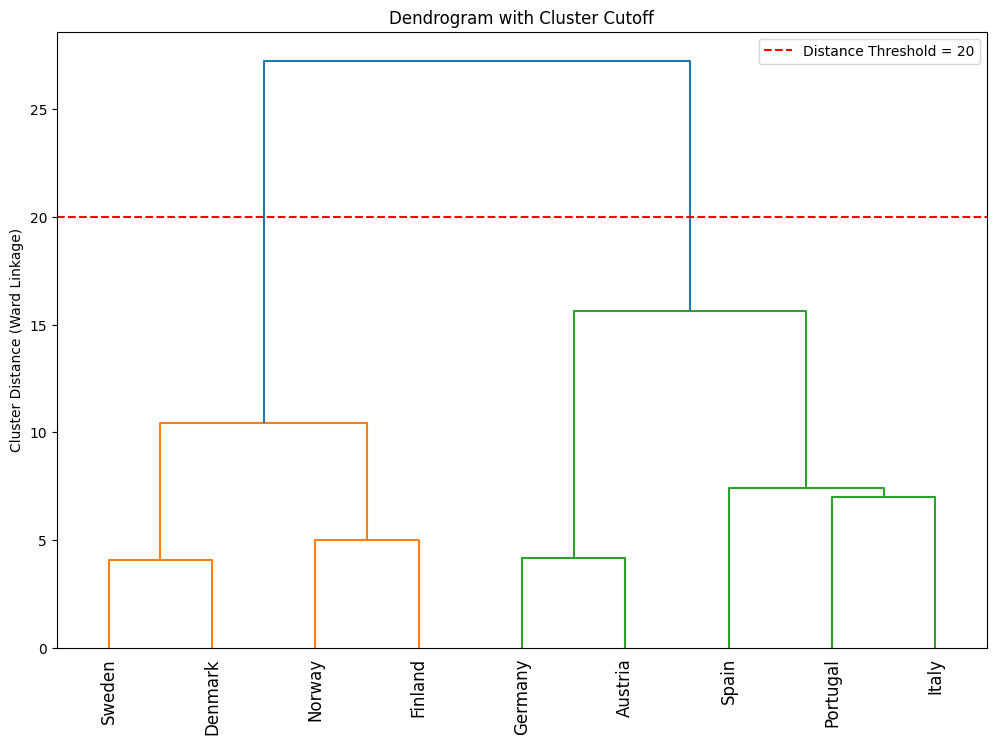

In [49]:
# 3. Plot the dendrogram and visualise the "cut"
distance_threshold = 20
fig, ax = plt.subplots(figsize=(12, 8))
dendrogram(mergings, labels=country_names, leaf_rotation=90, ax=ax)
ax.axhline(
    y=distance_threshold,
    color="r",
    linestyle="--",
    label=f"Distance Threshold = {distance_threshold}",
)
ax.set_title("Dendrogram with Cluster Cutoff")
ax.set_ylabel("Cluster Distance (Ward Linkage)")
ax.legend()
plt.show()

In [50]:
# 4. Extract cluster labels using the distance criterion
# Note: SciPy labels start at 1, not 0.
labels_by_distance = fcluster(mergings, distance_threshold, criterion="distance")

# 5. Extract cluster labels using the maxclust criterion (e.g., to get 3 clusters)
labels_by_k = fcluster(mergings, 3, criterion="maxclust")

# 6. Align and inspect the labels
results_df = pd.DataFrame(
    {
        "country": country_names,
        "label_by_distance": labels_by_distance,
        "label_by_k": labels_by_k,
    }
)

print("Cluster Labels by Distance Threshold:")
print(results_df.sort_values("label_by_distance")[["country", "label_by_distance"]])
print("\nCluster Labels by Number of Clusters (k=3):")
print(results_df.sort_values("label_by_k")[["country", "label_by_k"]])

Cluster Labels by Distance Threshold:
    country  label_by_distance
0    Sweden                  1
1   Denmark                  1
2    Norway                  1
3   Finland                  1
4     Spain                  2
5  Portugal                  2
6     Italy                  2
7   Germany                  2
8   Austria                  2

Cluster Labels by Number of Clusters (k=3):
    country  label_by_k
0    Sweden           1
1   Denmark           1
2    Norway           1
3   Finland           1
7   Germany           2
8   Austria           2
5  Portugal           3
4     Spain           3
6     Italy           3



The dendrogram with the red dashed line visually represents our cut at a distance of 20. The code then programmatically extracts the cluster labels. The output DataFrame shows the groupings formed by both methods. In this case, because of the data's clear structure, cutting at a distance of 20 happens to produce the same 3 clusters that we get when we explicitly ask for `k=3`. This confirms that we can use the dendrogram to derive a flat clustering that is both visually intuitive and computationally useful.

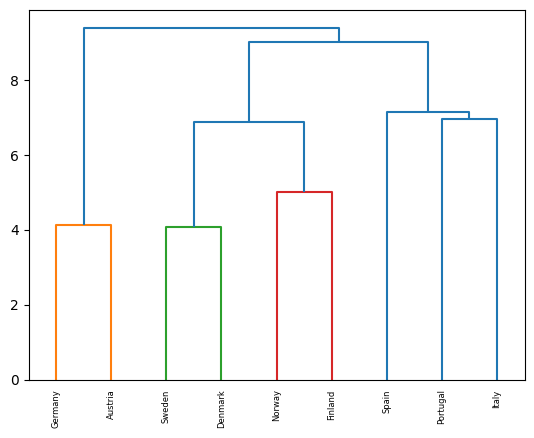

In [51]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate the linkage: mergings
mergings = linkage(scores, method="single")

# Plot the dendrogram
dendrogram(mergings, labels=country_names, leaf_rotation=90, leaf_font_size=6)
plt.show()

In [52]:
from scipy.cluster.hierarchy import linkage, fcluster

# Calculate the linkage for samples_2 (assuming this is the intended dataset)
mergings = linkage(samples_2, method="complete")

# Use fcluster to extract labels: labels
labels = fcluster(mergings, 6, "distance")

# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({"labels": labels, "varieties": varieties_2})

# Create crosstab: ct
ct = pd.crosstab(df["labels"], df["varieties"])

display(ct)

varieties,Canadian wheat,Kama wheat,Rosa wheat
labels,,,
1,14,3,0
2,0,0,14
3,0,11,0


**t-SNE (t-distributed Stochastic Neighbor Embedding) is an unsupervised, non-linear dimensionality reduction technique primarily used for visualizing high-dimensional datasets. It projects data into a 2D or 3D "map" that reveals its underlying cluster structure by preserving the local neighborhood relationships between data points.**

## The Intuition Behind t-SNE

The core idea of t-SNE is to place your high-dimensional data points onto a low-dimensional map (like a scatter plot) in a way that respects their "nearness." It tries to ensure that points that are close to each other in the original high-dimensional space are also close to each other on the 2D map. This makes it exceptionally good at untangling complex data manifolds and revealing the natural groupings or clusters within the data.

Unlike PCA, which is a linear technique focused on preserving the global variance, t-SNE is non-linear and focuses on preserving the local structure. This makes it superior for visualization, but it also comes with important caveats regarding its interpretation.

#### How to (and How Not to) Interpret t-SNE Plots

t-SNE is a powerful exploratory tool, but its output can be misleading if misinterpreted.

  - **DO look for clusters.** The primary strength of t-SNE is its ability to show distinct groupings in the data.
  - **DO observe the relative positions of clusters.** If two clusters are close together on the map, it suggests they are more similar to each other than to a cluster that is far away.
  - **DON'T interpret the global geometry.** The size of a cluster on a t-SNE plot does not necessarily correspond to the actual size or density of the cluster in the original space. Likewise, the distance *between* two separated clusters has no direct, quantifiable meaning. You cannot say "cluster A is twice as far from B as it is from C."
  - **DON'T interpret the axes.** The x and y axes of a t-SNE plot have no intrinsic meaning and are not aligned with any of the original features.

### A Complete Practical Example

Let's use t-SNE to visualise the Piedmont wines dataset. Since t-SNE is a distance-based algorithm, **scaling the data is a critical prerequisite**.


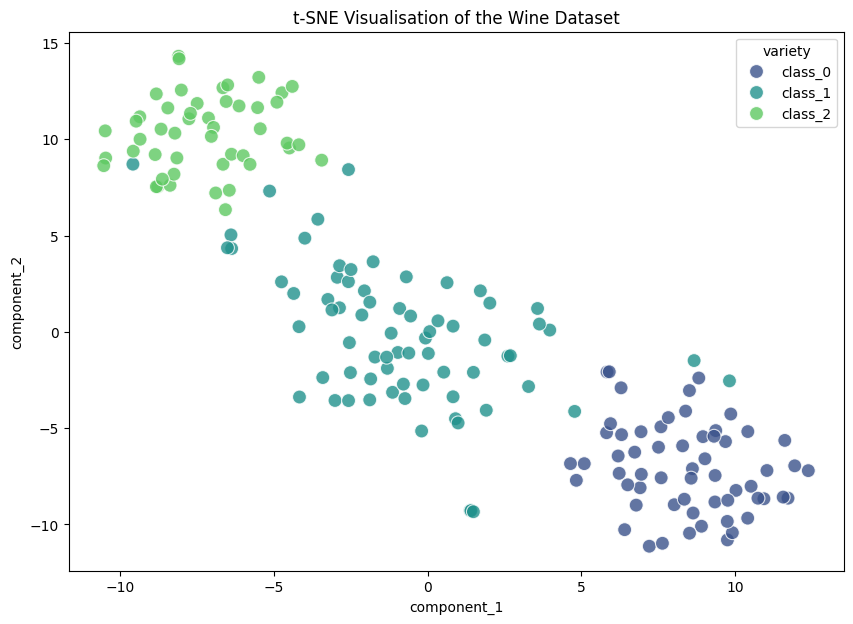

In [53]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. Load and Scale the Data
wine = load_wine()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(wine.data)

# 2. Apply t-SNE
# Use a random_state for reproducibility of this specific plot
tsne = TSNE(n_components=2, learning_rate=150, random_state=42)
features_tsne = tsne.fit_transform(features_scaled)

# 3. Create a DataFrame for visualisation
tsne_df = pd.DataFrame(data=features_tsne, columns=["component_1", "component_2"])
tsne_df["variety"] = [wine.target_names[i] for i in wine.target]

# 4. Visualise the t-SNE map
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df,
    x="component_1",
    y="component_2",
    hue="variety",
    palette="viridis",
    s=100,
    alpha=0.8,
    ax=ax,
)
ax.set_title("t-SNE Visualisation of the Wine Dataset")
plt.show()

The resulting plot clearly shows three distinct clusters. Even without being given the variety labels, t-SNE was able to learn the underlying structure of the data and place the samples from the same wine variety close to one another on the 2D map.

### Key Parameters and Considerations

Using t-SNE effectively requires understanding its key characteristics.

### The `learning_rate` Hyperparameter

The `learning_rate` is a crucial parameter that you may need to tune. A value that is too low or too high can fail to capture the structure of the data. A common sign of a poor `learning_rate` is a plot where all points are collapsed into a single, dense "ball." Typical values to try are between 50 and 200.

### The Stochastic Nature of t-SNE

The t-SNE algorithm has a random initialisation step, meaning that running it multiple times on the same data will produce visually different plots (e.g., different rotations). However, the important information—the relative positions of the clusters—should remain consistent. Always use a `random_state` in your code to ensure your specific results are reproducible.

### The `fit_transform` API

Unlike many `scikit-learn` components, `TSNE` **only has a `.fit_transform()` method**. It does not have separate `.fit()` and `.transform()` methods. This means you cannot train a t-SNE model and then apply it to new, unseen data. If you get new data, you must add it to your existing dataset and re-run the entire t-SNE process from scratch. This reinforces its role as an **exploratory analysis and visualisation tool**, not a preprocessing step for a production model.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(learning_rate=200)

